In [51]:
from __future__ import division

import time
import warnings

import pandas as pd
import numpy as np
import py_stringmatching as sm
import py_entitymatching as em
import py_stringsimjoin as ssj

from copy import deepcopy
from py_entitymatching.catalog import catalog_manager as cm # tiene traccia delle tabelle caricate e delle relazioni tra loro

warnings.filterwarnings('ignore')


<a id="entity-resolution-in-magellan-py-entitymatching"></a>
<a id="entity-resolution-in-magellan-py-entitymatching"></a>
# Entity Resolution in Magellan: py_entitymatching

Il processo di Entity Resolution (Entity Matching) in Magellan considera **due dataset come input** e produce **una Table Match in output** ed è costituito da due fasi

1.  **Blocking**

2.  **Matching**


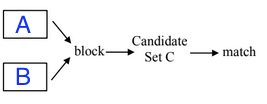




La maggior parte delle funzionalità di Magellan sono riferite a questo schema con due dataset. I due dataset devono avere entrambi una primary key, e gli altri dataset che contengono coppie di record_id avranno le foreign key riferite ai due dataset.

<a id="dataset"></a>
<a id="dataset"></a>
<a id="dataset"></a>
## Dataset

Si considerano i seguenti due dataset, già allineati a livello di schema, cioè hanno lo stesso schema ovvero gli stessi attributi (vedremo poi come gestire il caso generale di schemi allineati ma con differenti  attributi) , con il relativo Gold Standard.


In [52]:
A=pd.read_csv('http://dbgroup.ing.unimore.it/SIWS/DataIntegration/fodors.csv')
B=pd.read_csv('http://dbgroup.ing.unimore.it/SIWS/DataIntegration/zagats.csv')
# ed il relativo gold standard (predicted matches)
GoldStandard=pd.read_csv('http://dbgroup.ing.unimore.it/SIWS/DataIntegration/matches_fodors_zagats.csv')
# per uniformare i nomi rispetto alla terminologia/convenzione usata in Magellan
# l_ e r_ per indicare rispettivamente il primo (left) ed il secondo (right) dataset
GoldStandard.columns=['l_id','r_id']
A=A.rename(columns={'id': 'l_id'})
B=B.rename(columns={'id': 'r_id'})

print(A.columns)
print(B.columns)
GoldStandard.sample(5)

Index(['l_id', 'name', 'addr', 'city', 'phone', 'type'], dtype='object')
Index(['r_id', 'name', 'addr', 'city', 'phone', 'type'], dtype='object')


,l_id,r_id
25,560,245
19,554,239
62,597,282
79,614,299
73,608,293


In [53]:
C  = ssj.jaccard_join(A, B, 'l_id', 'r_id', 
                      'name', 'name', 
                      sm.QgramTokenizer(qval=3), 
                      threshold=0.4,
                                  l_out_attrs=['name', 'addr' , 'city'],
                                  r_out_attrs=['name', 'addr' , 'city'])


In [54]:
C.head()

,_id,l_l_id,r_r_id,l_name,l_addr,l_city,r_name,r_addr,r_city,_sim_score
0,0,963,7,bistro,3400 las vegas blvd. s,las vegas,bistro 45,45 s. mentor ave.,pasadena,0.461538
1,1,991,7,bistro roti,155 steuart st.,san francisco,bistro 45,45 s. mentor ave.,pasadena,0.411765
2,2,962,9,binions coffee shop,128 fremont st.,las vegas,brighton coffee shop,9600 brighton way,beverly hills,0.433333
3,3,731,11,bruno,240 e. 58th st.,new york,brunos,3838 centinela ave.,mar vista,0.500000
4,4,741,12,cafe fes,246 w. 4th st. at charles st.,new york,cafe 50s,838 lincoln blvd.,venice,0.428571


In [55]:
ValutaBlocking(A,B,C,GoldStandard)


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,137,0.9992,0.8739,0.708


In [56]:
A['mix']=' '
B['mix']=' '
for x in ['name', 'addr' , 'city']:
    A['mix'] += A[x] + ' '
    B['mix'] += B[x] + ' '

A['mix'] = ''
B['mix'] = ''
for x in ['name', 'addr', 'city']:
    A['mix'] += A[x].fillna('') + ' '
    B['mix'] += B[x].fillna('') + ' '

In [57]:
C  = ssj.jaccard_join(A, B, 'l_id', 'r_id', 
                      'mix', 'mix', 
                      sm.QgramTokenizer(qval=3), 
                      threshold=0.4,
                                  l_out_attrs=['name', 'addr' , 'city'],
                                  r_out_attrs=['name', 'addr' , 'city'])


In [58]:
ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,273,0.9984,0.973,0.3956


In [59]:
C

,_id,l_l_id,r_r_id,l_name,l_addr,l_city,r_name,r_addr,r_city,_sim_score
0,0,654,5,broadway deli,3rd st. promenade,santa monica,benitas frites,1433 third st. promenade,santa monica,0.436620
1,1,696,5,remi,3rd st. promenade,santa monica,benitas frites,1433 third st. promenade,santa monica,0.476190
2,2,553,6,rex il ristorante,617 s. olive st.,los angeles,bernards,515 s. olive st.,los angeles,0.412698
3,3,541,18,fenix,8358 sunset blvd. west,hollywood,dukes,8909 sunset blvd.,w. hollywood,0.428571
4,4,660,55,cava,3rd st.,los angeles,r-23,923 e. third st.,los angeles,0.441860
...,...,...,...,...,...,...,...,...,...,...
268,268,644,329,ritz-carlton restaurant and dining room,600 stockton st.,san francisco,ritz-carlton dining room (san francisco),600 stockton st.,san francisco,0.697368
269,269,645,330,rose pistola,532 columbus ave.,san francisco,rose pistola,532 columbus ave.,san francisco,1.000000
270,270,1024,330,losteria del forno,519 columbus ave.,san francisco,rose pistola,532 columbus ave.,san francisco,0.408451
271,271,623,331,cafe ritz-carlton buckhead,3434 peachtree rd.,atlanta,ritz-carlton cafe (atlanta),181 peachtree st.,atlanta,0.434211


In [60]:
A.head()

,l_id,name,addr,city,phone,type,mix
0,535,arts delicatttessen,12224 ventura blvd.,studio city,818/762-1221,american,arts delicatttessen 12224 ventura blvd. studio city
1,536,hotel bel-air,701 stone canyon rd.,bel air,310/472-1211,californian,hotel bel-air 701 stone canyon rd. bel air
2,537,cafe bizzou,14016 ventura blvd.,sherman oaks,818/788-3536,french,cafe bizzou 14016 ventura blvd. sherman oaks
3,538,campanile,624 s. la brea ave.,los angeles,213/938-1447,american,campanile 624 s. la brea ave. los angeles
4,539,chinois on main,2709 main st.,santa monica,310/392-9025,french,chinois on main 2709 main st. santa monica


In [61]:
CorrispondenzeAttributi = em.get_attr_corres(A, B)
CorrispondenzeAttributi['corres']

[('name', 'name'),
 ('addr', 'addr'),
 ('city', 'city'),
 ('phone', 'phone'),
 ('type', 'type'),
 ('mix', 'mix')]

In [62]:
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)
print(atypesA['phone'],atypesB['phone'])
# str_bt_1w_5w : short string (1 word to 5 words)         str_eq_1w:	short string (1 word)

str_bt_1w_5w str_eq_1w


In [63]:
# se voglio uniformare: metto il tipo in B di phone uquale a quello in A
# atypesB['phone']=atypesA['name']
# faremo questa operazione quando necessaria

Si deve  sempre verificare che il Gold Standard non contenga elementi non esistenti nei rispettivi dataset, ovvero che rispetti la classica integrità referenziale; si effettuano due left join e si controlla che il risultato sia nullo (altrimenti occorre cancellare le coppie del Gold Standard che non rispettano l'integrità referenziale):

In [64]:
pd.merge(GoldStandard,A, how='left', indicator=True).query("_merge=='left_only'"),  \
pd.merge(GoldStandard,B, how='left', indicator=True).query("_merge=='left_only'")

(Empty DataFrame
 Columns: [l_id, r_id, name, addr, city, phone, type, mix, _merge]
 Index: [],
 Empty DataFrame
 Columns: [l_id, r_id, name, addr, city, phone, type, mix, _merge]
 Index: [])

I due dataset devono avere entrambi una primary key, e gli altri dataset che contengono coppie di record_id (Gold Standard, Candidate Set, ...) avranno una foreign key riferita ai due dataset. In Magellan esistono delle funzioni per dichiarare/settare queste key & foreign key, presentate nella prossima sezione.

<a id="data-structures"></a>
<a id="data-structures"></a>
## Data Structures

[Data Structures](http://anhaidgroup.github.io/py_entitymatching/v0.3.3/user_manual/datastructures.html#storing-metadata-using-a-catalog)



> In py_entitymatching, we will need to store many tables and metadata associated with it. It is important for you to know the data structures that are used to store the tables and the metadata, so that you can manipulate them based on your need.



> Each table in py_entitymatching should have a **key**, so that we can easily identify the tuples.

> The blocking step will create tuple pairs from two tables A and B. For example, suppose we have table *A(aid, a, b)* and table *B(bid, x, y)*, then the tuple pairs can be stored in a candidate set table *C(cid, aid, bid, a, b, x, y)*. This table could be very big, taking up a lot of space in memory. To save space, we may want to just store C as *C(cid, aid, bid)* and then have pointers back to tables A and B. The two pointers back to A and B are **foreign keys** (aid, bid) to the base tables (A, B).





Quanto detto sopra per il Candidate Set vale anche per il *Gold Standard*, per la *MatchTable* vera e propria ottenuta dal metodo di data matching o l'insieme *labelled* usato nelle tecniche di Machine Learning.

Facciamo un esempio, considerando il GoldStandard:

In [65]:
# Per definire la key del GoldStandard si aggiunge un id :
GoldStandard['id']=range(len(GoldStandard))
# e si setta come key
em.set_key(GoldStandard, 'id')

# si settano le key dei due dataset
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')

# si settano le foreign key in GoldStandard
em.set_ltable(GoldStandard, A)
em.set_rtable(GoldStandard, B)
em.set_fk_ltable(GoldStandard, 'l_id')
em.set_fk_rtable(GoldStandard, 'r_id')
# nota che viene controllato se il constraint sia valido, infatti
# em.set_key(A, 'city')
# produce
# Attribute (city ) does not qualify  to be a key; Not setting/replacing the key
# False


True

In [66]:
# un modo più sintetico per settare key e foreign key
cm.set_candset_properties(GoldStandard, 'id', 'l_id', 'r_id', A, B)

True

<a id="add-output-attributes-facoltativo"></a>
<a id="add-output-attributes-facoltativo"></a>
## add_output_attributes (facoltativo)


Questa struttura dati viene utilizzata in molte funzioni di Magellan. Come primo esempio vediamo la funzione **add_output_attributes** : serve per aggiungere ad una table che contiene coppie di key (come il Gold Standard) gli  attributi (di tutti o alcuni) presi dalle due table corrispondenti.
Questa operazione si potrebbe fare con un  join
```
pd.merge(pd.merge(GoldStandard,A),B, on='r_id').sample(3)
```
ma per semplificare, essendo  frequente è stata introdotta tale funzione

Se si vogliono aggiungere a GoldStandard attributi presi dalle table A e B si devono settare key e foreign key.


In [67]:
em.add_output_attributes(GoldStandard, l_output_attrs=['name', 'addr', 'city', 'phone', 'type'],
								   r_output_attrs=['name', 'addr', 'city', 'phone', 'type'],
								   l_output_prefix='l_', r_output_prefix='r_',
                   delete_from_catalog=False).sample(3)


,l_id,r_id,id,l_name,l_addr,l_city,l_phone,l_type,r_name,r_addr,r_city,r_phone,r_type
11,546,231,11,le chardonnay,8284 melrose ave.,los angeles,213/655-8880,french,le chardonnay (los angeles),8284 melrose ave.,los angeles,213-655-8880,french bistro
66,601,286,66,chins,3200 las vegas blvd. s,las vegas,702/733-8899,asian,chins,3200 las vegas blvd. s.,las vegas,702-733-8899,chinese
93,628,313,93,alain rondelli,126 clement st.,san francisco,415/387-0408,french,alain rondelli,126 clement st.,san francisco,415-387-0408,french (new)


In [68]:
# la stessa cosa la possiamo fare sul prodotto cartesiano delle chiavi di A e B
ProdottoCartesianoKeyAB= A[['l_id']].assign(key=1).merge(B[['r_id']].assign(key=1), on='key').drop('key', 1)
ProdottoCartesianoKeyAB['id']=range(len(ProdottoCartesianoKeyAB))
cm.set_candset_properties(ProdottoCartesianoKeyAB, 'id', 'l_id', 'r_id', A, B)
em.add_output_attributes(ProdottoCartesianoKeyAB, l_output_attrs=['name', 'addr', 'city'],
								   r_output_attrs=['name', 'addr', 'city'],
								   l_output_prefix='l_', r_output_prefix='r_',
                   delete_from_catalog=False).sample()

,l_id,r_id,id,l_name,l_addr,l_city,r_name,r_addr,r_city
97216,829,197,97216,lincoln tavern,51 w. 64th st.,new york,erics chinese restaurant,1500 church st.,san francisco


> Nota: Noi definiremo questi metadata (key, foreign key, ...) esplicitamente come fatto in precedenza. D'altra parte Magellan ha alcune funzionalità particolari per gestire tali metadata, si veda ad esempio
[read_csv_metadata](http://anhaidgroup.github.io/py_entitymatching/v0.1.x/user_manual/api/reading_and_writing_data.html#py_entitymatching.read_csv_metadata)




<a id="blocking"></a>
<a id="blocking"></a>
<a id="blocking"></a>
# Blocking

La fase di Blocking considera **due dataset A e B come input** e produce **un Candidate Set**

La fase di blocking  può essere effettuata secondo una delle seguenti modalità

1. [**Specifying Blockers and Performing Blocking**](https://anhaidgroup.github.io/py_entitymatching/v0.3.x/user_manual/blocking.html)
si utilizzano specifiche funzioni di Magellan per costruire, gestire e combinare tra di loro dei *blockers*;
noi ci soffermeremo sui *RuleBasedBlocker*


2.  **Blocking by Similarity Join**: il Candidate Set viene calcolato come similarity join tra i dataset di input

3.  In alcuni casi ed in molti esempi di dataset forniti da Magellan, il **Candidate Set C  già disponibile**; in altri casi, sopratutto per dataset di limitate dimensioni, la fase di blocking viene omessa e si considera come Candadate Set l'intero *prodotto cartesiano*

<a id="attrequivalenceblocker-blocking-key"></a>
<a id="attrequivalenceblocker-blocking-key"></a>
<a id="attrequivalenceblocker-blocking-key"></a>
## AttrEquivalenceBlocker (Blocking Key)

E' il più semplice dei blocker :
sceglendo come *Blocking Key* l'attributo City
si controlla *A.City==B.City* e si *bloccano* le coppie di record che non soddisfano tale condizione



In [69]:
# viene istanziato un  AttrEquivalenceBlocker

ab = em.AttrEquivalenceBlocker()

# si effettua il blocking tramite il metodo block_tables
C = ab.block_tables(  A, B, # dataset
      'city', 'city', # si controlla A.City==B.City e si bloccano quelle che non soddisfano
      l_output_attrs=['name', 'addr', 'city', 'phone'],
      r_output_attrs=['name', 'addr', 'city', 'phone']
    ).rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})

C.head()

,_id,l_id,r_id,ltable_name,ltable_addr,ltable_city,ltable_phone,rtable_name,rtable_addr,rtable_city,rtable_phone
0,0,535,32,arts delicatttessen,12224 ventura blvd.,studio city,818/762-1221,killer shrimp,4000 colfax ave.,studio city,818-508-1570
1,1,535,62,arts delicatttessen,12224 ventura blvd.,studio city,818/762-1221,sushi nozawa,11288 ventura blvd.,studio city,818-508-7017
2,2,535,220,arts delicatttessen,12224 ventura blvd.,studio city,818/762-1221,arts deli,12224 ventura blvd.,studio city,818-762-1221
3,3,535,237,arts delicatttessen,12224 ventura blvd.,studio city,818/762-1221,pinot bistro,12969 ventura blvd.,studio city,818-990-0500
4,4,536,221,hotel bel-air,701 stone canyon rd.,bel air,310/472-1211,bel-air hotel,701 stone canyon rd.,bel air,310-472-1211


<a id="blocking-evaluation"></a>
<a id="blocking-evaluation"></a>
<a id="blocking-evaluation"></a>
## Blocking Evaluation

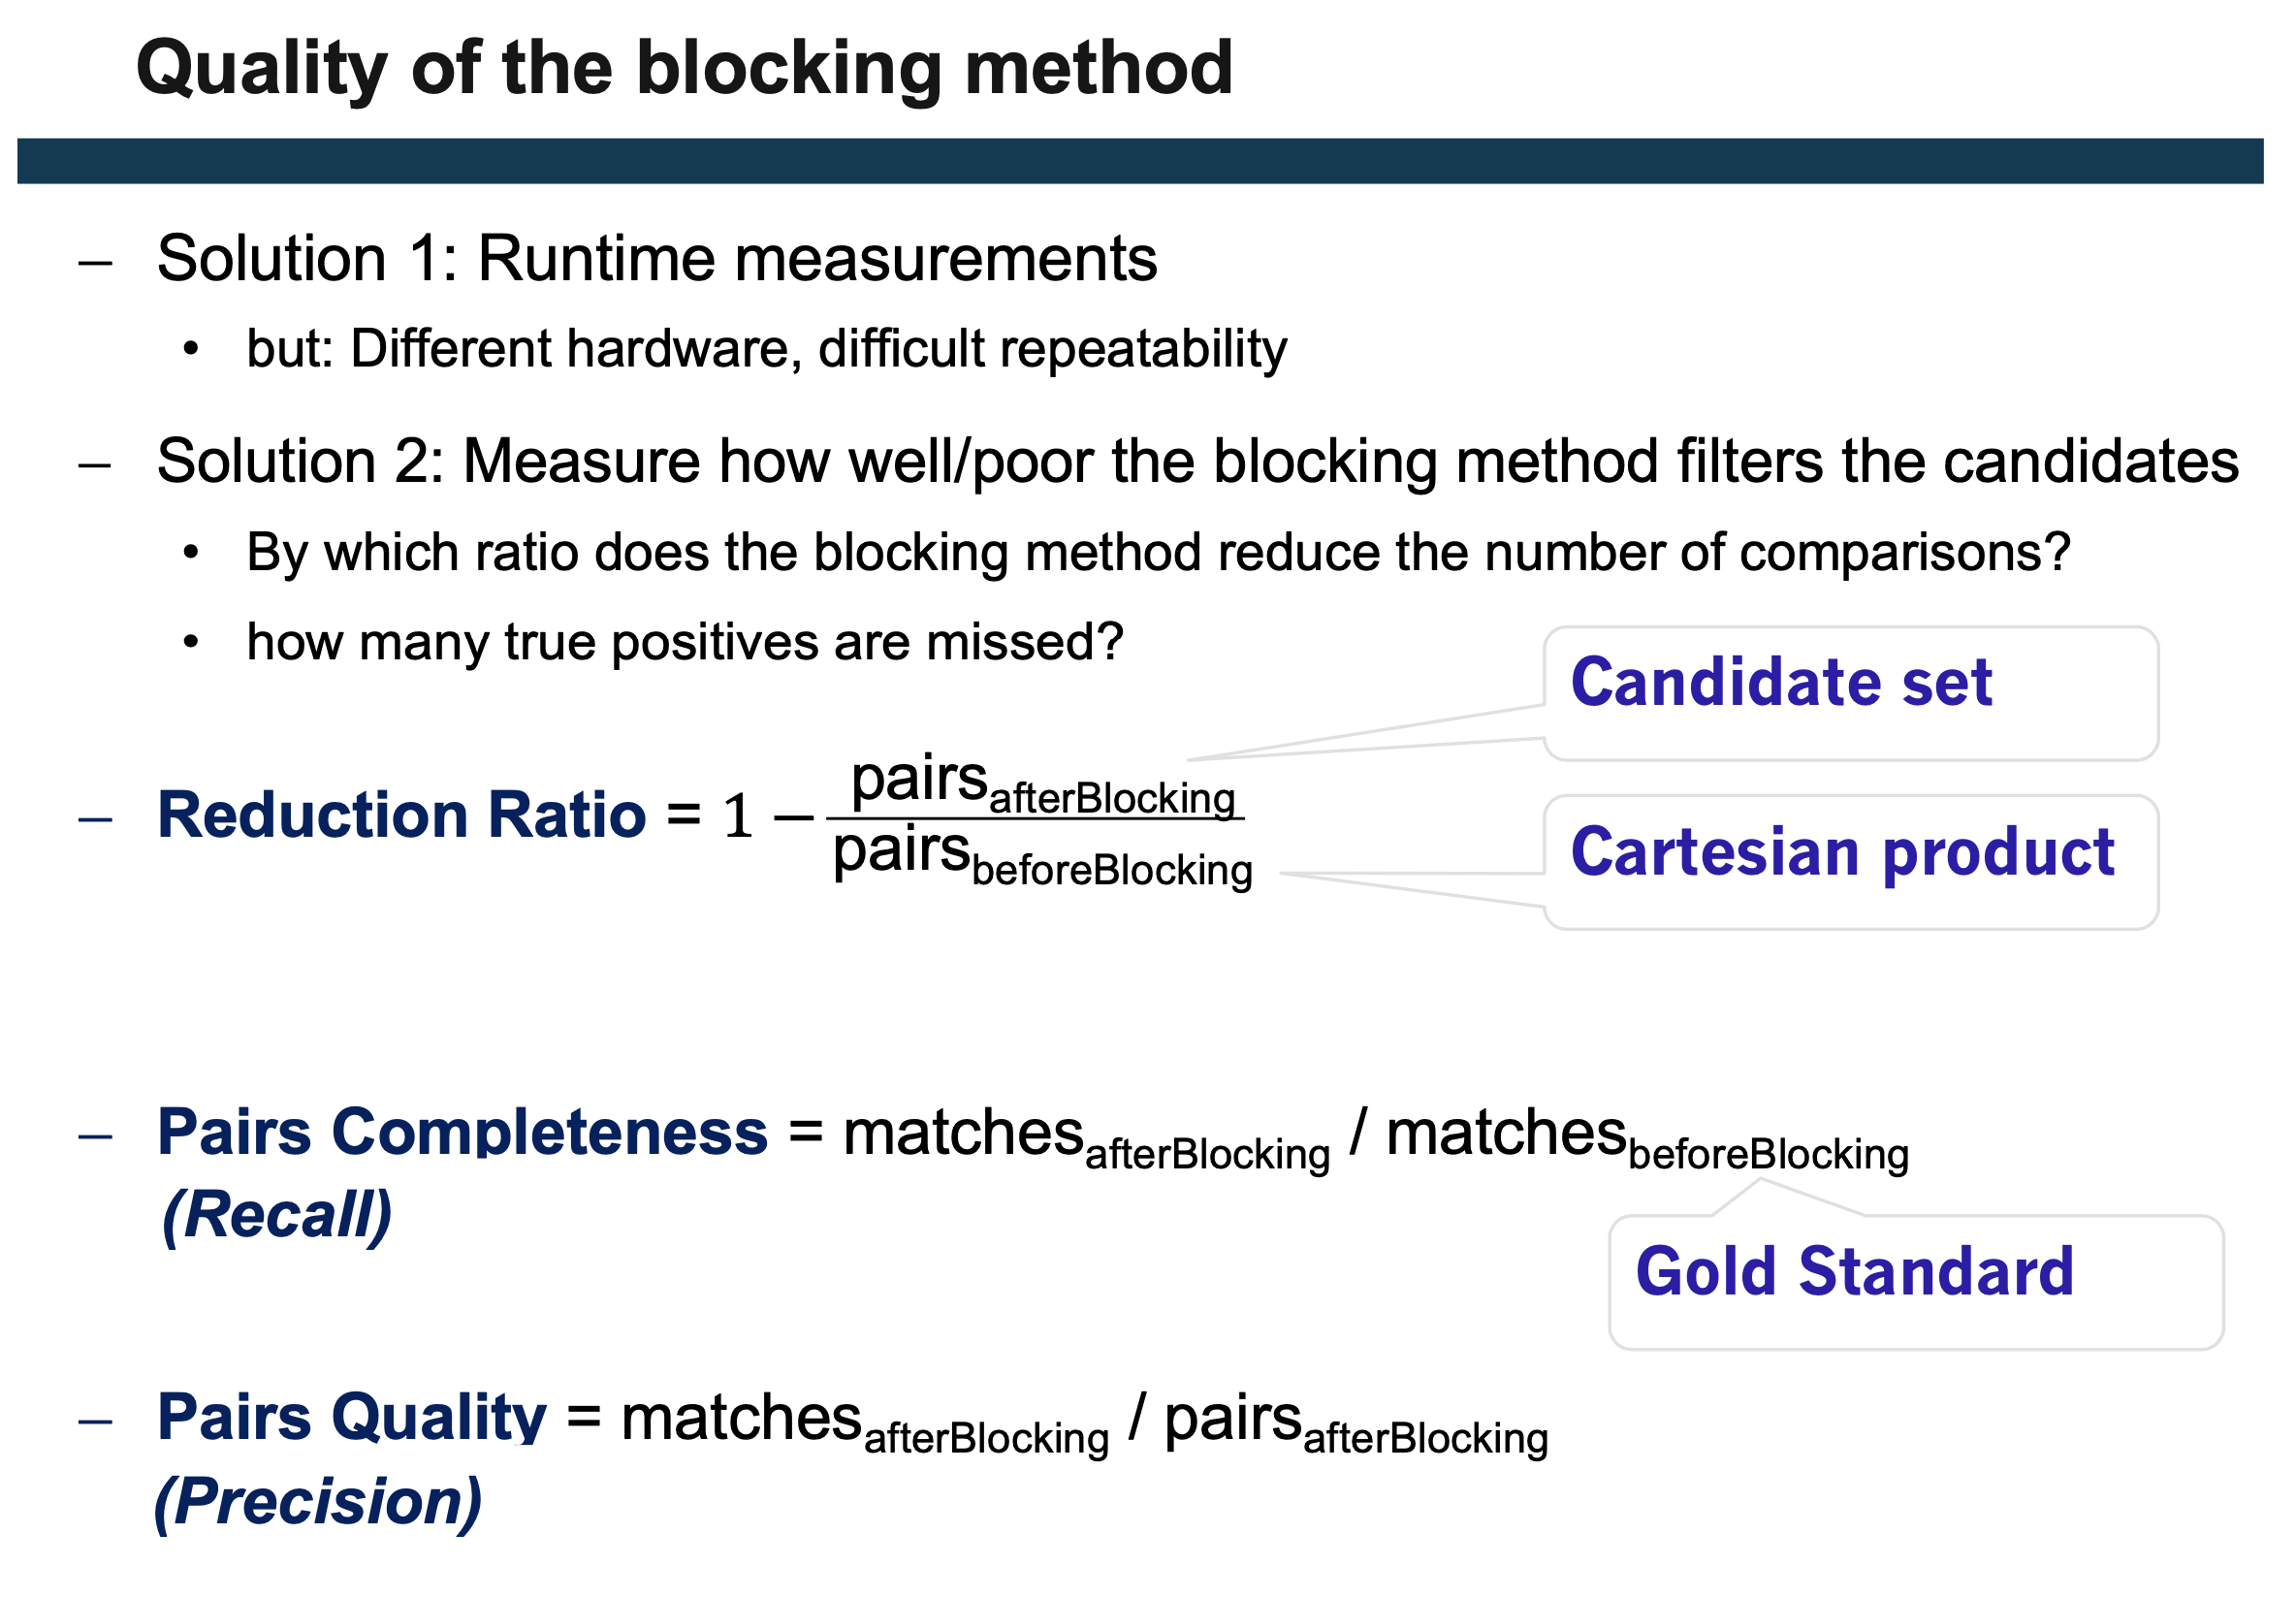


In [70]:
# Evaluation del blocking
print('Pairs_Before_Blocking (Cartesian Product): ' + str(len(A)*len(B)))
print('Pairs_After_Blocking (Candidate Set): ' + str(len(C)))
print('Reduction_Ratio: ' + str(1 - len(C)/(len(A)*len(B))))

print('Matches_Before_Blocking (Gold Standard): ' + str(len(GoldStandard)))
# Matches_After_Blocking: sono i Matches_Before_Blocking che trovo anche in C
Matches_After_Blocking=pd.merge(GoldStandard, C[['l_id','r_id']])

print('Matches_After_Blocking: ' + str(len(Matches_After_Blocking)))

print('Pairs Completeness: ' + str(len(Matches_After_Blocking)/len(GoldStandard)))
print('Pairs Quality: ' + str(len(Matches_After_Blocking)/len(C)))

Pairs_Before_Blocking (Cartesian Product): 175560
Pairs_After_Blocking (Candidate Set): 10092
Reduction_Ratio: 0.9425153793574846
Matches_Before_Blocking (Gold Standard): 111
Matches_After_Blocking: 59
Pairs Completeness: 0.5315315315315315
Pairs Quality: 0.0058462148236226716


Definiamo una funzione per fare queste valutazioni:

In [71]:
def ValutaBlocking(DA,DB,Block,Gold):
# INPUT : entrambi Block (è il candidate set after blocking)
#        e Gold (Gold Standard) devono essere con due colonne, l_id e r_id
# per avere indipendenza dal nome di queste colonne
# Si suppone che in Block l_id e r_id siano rispettivamente la seconda e la terza colonna
# e che in Gold sia la prima e la seconda
  Block = Block.iloc[:, [1, 2]].copy()
  Gold = Gold.iloc[:, [0, 1]].copy()
  Gold.columns=Block.columns=['l_id','r_id']

  JOIN=pd.merge(Gold, Block)

 # Reduction_Ratio
  RR=1-len(Block)/(len(DA)*len(DB))
 # Pairs Completeness o Recall
  PC = len(JOIN)/len(Gold)
 # Pairs Quality
  PQ = len(JOIN)/len(Block)

  Risultato = pd.DataFrame([(DA.shape[0],DB.shape[0],Block.shape[0],round(RR,4),round(PC,4),round(PQ,4))],
                             columns=['A', 'B', 'BlockSize', 'ReductRatio','PCompletness','PQuality'])

  return Risultato

In [72]:
ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,10092,0.9425,0.5315,0.0058


Verifichiamo che AttrEquivalenceBlocker corrisponde ad un semplice join

In [73]:
Cjoin=A.merge(B,on='city', how='inner')

print(len(C),len(Cjoin))
print("Verifica che C e Cjoin siano esattamente lo stesso insieme di coppie tramite outer join:")
print(len(Cjoin.merge(C, on=['l_id', 'r_id'], how='outer' , indicator=True).query(" _merge != 'both' ")))

10092 10092
Verifica che C e Cjoin siano esattamente lo stesso insieme di coppie tramite outer join:
0


In [74]:
# per fare il blocking su due chiavi, ad esempio ['city','addr']
Cjoin=A.merge(B,on=['city','addr'], how='inner')
len(Cjoin)

39

In Magellan però questo non è possibile, cioè non posso mettere una coppia di attributi come blocking key in un AttrEquivalenceBlocker, dovrei utilizzare ([**Multiple** blockers and **Combine**](http://nbviewer.jupyter.org/github/anhaidgroup/py_entitymatching/blob/master/notebooks/guides/step_wise_em_guides/Combining%20Multiple%20Blockers.ipynb)). Vedremo come questo sia possibile comunque farlo tramite un *RuleBasedBlocker*





<a id="debug-blocker"></a>
<a id="debug-blocker"></a>
## debug_blocker

[debug_blocker](http://anhaidgroup.github.io/py_entitymatching/v0.1.x/user_manual/debugging_blocking.html)


Effettuando un blocking *A.City==B.City* è ovvio che perdo anche coppie di record con City differente ma *simili* : per individuare tali coppie c'è la seguente funzione di debugging:





In [75]:
ab = em.AttrEquivalenceBlocker()
C = ab.block_tables(  A, B, # dataset
      'city', 'city', # si controlla A.City==B.City e si bloccano quelle che non soddisfano
      l_output_attrs=['name', 'city'],
      r_output_attrs=['name',  'city']
    )
em.debug_blocker(C, A, B, output_size=3)

,_id,ltable_l_id,rtable_r_id,ltable_name,ltable_addr,ltable_city,ltable_phone,ltable_type,ltable_mix,rtable_name,rtable_addr,rtable_city,rtable_phone,rtable_type,rtable_mix
0,0,579,264,manhattan ocean club,57 w. 58th st.,new york,212/ 371-7777,seafood,manhattan ocean club 57 w. 58th st. new york,manhattan ocean club,57 w. 58th st.,new york city,212-371-7777,seafood,manhattan ocean club 57 w. 58th st. new york city
1,1,599,284,union square cafe,21 e. 16th st.,new york,212/243-4020,american,union square cafe 21 e. 16th st. new york,union square cafe,21 e. 16th st.,new york city,212-243-4020,american (new),union square cafe 21 e. 16th st. new york city
2,2,569,254,gotham bar & grill,12 e. 12th st.,new york,212/620-4020,american,gotham bar & grill 12 e. 12th st. new york,gotham bar & grill,12 e. 12th st.,new york city,212-620-4020,american (new),gotham bar & grill 12 e. 12th st. new york city


Per non perdere queste coppie si deve fare un  blocking non più esatto ma basato sulla similarità: Overlap Blocking

<a id="overlap-blocking"></a>
<a id="overlap-blocking"></a>
## Overlap Blocking



> Given two tables A and B, conceptually, block_tables in overlap blocker takes an attribute x of table A, an attribute y of table B, and returns True (that is, drop the tuple pair) if x and y do not share any token (where the token is a word or a q-gram).



In [76]:
# Instantiate overlap blocker object
ob = em.OverlapBlocker()
# Specify the tokenization to be 'word' level and set overlap_size to be 2.
C_OB = ob.block_tables(A, B,
                       'city', 'city',
                       word_level=True,
                       overlap_size=2,
                    l_output_attrs=['name', 'addr', 'city', 'phone'],
                    r_output_attrs=['name', 'addr', 'city', 'phone'],
                    show_progress=False)
em.debug_blocker(C_OB, A, B, output_size=3)

,_id,ltable_l_id,rtable_r_id,ltable_name,ltable_addr,ltable_city,ltable_phone,ltable_type,ltable_mix,rtable_name,rtable_addr,rtable_city,rtable_phone,rtable_type,rtable_mix
0,0,620,305,mary macs tea room,224 ponce de leon ave.,atlanta,404/876-1800,southern,mary macs tea room 224 ponce de leon ave. atlanta,mary macs tea room,224 ponce de leon ave.,atlanta,404-876-1800,southern/soul,mary macs tea room 224 ponce de leon ave. atlanta
1,1,542,227,granita,23725 w. malibu rd.,malibu,310/456-0488,californian,granita 23725 w. malibu rd. malibu,granita,23725 w. malibu rd.,malibu,310-456-0488,californian,granita 23725 w. malibu rd. malibu
2,2,627,312,veni vidi vici,41 14th st.,atlanta,404/875-8424,italian,veni vidi vici 41 14th st. atlanta,veni vidi vici,41 14th st.,atlanta,404-875-8424,italian,veni vidi vici 41 14th st. atlanta


In [77]:
# Perchè perdo le coppie con la stessa citta atlanta?
# overlap_size=2 applicato ad una stringa con un solo termine, sempre falso ...
# Allora provo con un Q-gram based tokenizer
# Instantiate overlap blocker object
ob = em.OverlapBlocker()
C_OB = ob.block_tables(A, B, 'city', 'city',
                       word_level=False,
                       q_val=3,
                       overlap_size=2,
                    l_output_attrs=['name', 'addr', 'city', 'phone'],
                    r_output_attrs=['name', 'addr', 'city', 'phone'],
                    show_progress=False)
em.debug_blocker(C_OB, A, B, output_size=3)

,_id,ltable_l_id,rtable_r_id,ltable_name,ltable_addr,ltable_city,ltable_phone,ltable_type,ltable_mix,rtable_name,rtable_addr,rtable_city,rtable_phone,rtable_type,rtable_mix
0,0,556,241,yujean kangs gourmet chinese cuisine,67 n. raymond ave.,los angeles,818/585-0855,asian,yujean kangs gourmet chinese cuisine 67 n. raymond ave. los angeles,yujean kangs,67 n. raymond ave.,pasadena,818-585-0855,chinese,yujean kangs 67 n. raymond ave. pasadena
1,1,552,237,pinot bistro,12969 ventura blvd.,los angeles,818/990-0500,french,pinot bistro 12969 ventura blvd. los angeles,pinot bistro,12969 ventura blvd.,studio city,818-990-0500,french bistro,pinot bistro 12969 ventura blvd. studio city
2,2,545,230,lorangerie,903 n. la cienega blvd.,los angeles,310/652-9770,french,lorangerie 903 n. la cienega blvd. los angeles,lorangerie,903 n. la cienega blvd.,w. hollywood,310-652-9770,french (classic),lorangerie 903 n. la cienega blvd. w. hollywood


In [78]:
ValutaBlocking(A,B,C_OB,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,34750,0.8021,0.9279,0.003


In [79]:
ob = em.OverlapBlocker()
C_OB_addres = ob.block_tables(A, B, 'addr', 'addr',
                       word_level=False, q_val=3, overlap_size=3,
                    l_output_attrs=['name', 'addr', 'city', 'phone'],
                    r_output_attrs=['name', 'addr', 'city', 'phone'],
                    show_progress=False)
ValutaBlocking(A,B,C_OB_addres,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,21375,0.8782,0.964,0.005


<a id="rulebasedblocker"></a>
<a id="rulebasedblocker"></a>
<a id="rulebasedblocker"></a>
#  RuleBasedBlocker

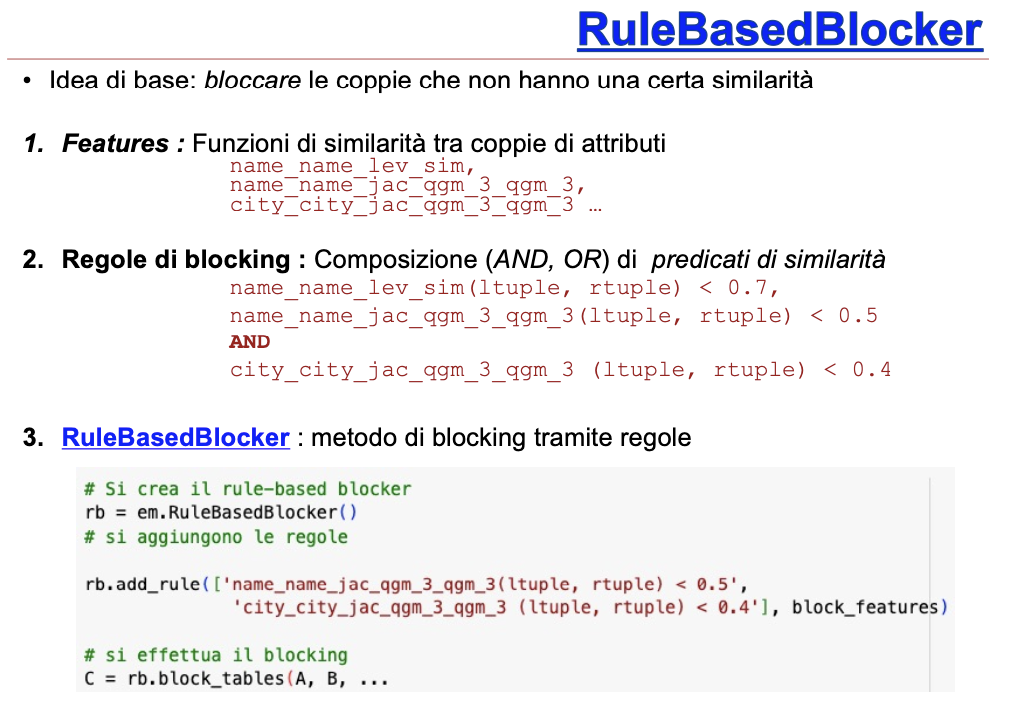








Nel seguito riportiamo anche le specifiche prese dal manuale [RuleBasedBlocker](https://anhaidgroup.github.io/py_entitymatching/v0.3.x/user_manual/blocking.html#rule-based-blockers)




> You can write a few domain specific rules (for blocking purposes) using rule-based blocker. If you want to write rules, then you must start by defining a set of features. Each feature is a function that when applied to a tuple pair will return a numeric value. We will discuss how to create a set of features in the section Creating Features for Blocking.

> Once the features are created, py_entitymatching stores this set of features in a feature table. We refer to this feature table as block_f.
Then you will be able to instantiate a rule-based blocker and add rules like this:

```
rb = em.RuleBasedBlocker()
rb.add_rule(rule1, block_f)
rb.add_rule(rule2, block_f)
```


> In the above, block_f is a set of features stored as a Dataframe (see section Creating Features for Blocking).

> Each rule is a list of strings. Each string specifies a conjunction of predicates. Each predicate has three parts: (1) an expression, (2) a comparison operator, and (3) a value. The expression is evaluated over a tuple pair, producing a numeric value. Currently, in py_entitymatching an expression is limited to contain a single feature (being applied to a tuple pair). So an example predicate will look like this:


```
name_name_lev(ltuple, rtuple) > 3
```


> In the above name_name_lev is feature. Concretely, this feature computes Levenshtein distance between the name values in the input tuple pair.

> As an example, the rules rule1 and rule2 can look like this:


```
rule1 = ['name_name_lev(ltuple, rtuple) > 3', 'age_age_exact_match(ltuple, rtuple) !=0']
rule2 = ['address_address_lev(ltuple, rtuple) > 6']
```


> In the above, rule1 contains two predicates and rule2 contains just a single predicate. Each rule is a conjunction of predicates. That is, each rule will return True only if all the predicates return True. The blocker is then a disjunction of rules. That is, even if one of the rules return True, then the tuple pair will be blocked.

> Once the rules are specified, you can call **block_tables** on the input tables. Conceptually, block_tables would apply the rule-based blocker function on the Cartesian product of the input tables A and B and return a candidate set of tuple pairs.

<a id="get-features-for-blocking-http-anhaidgroup-github-io-py-entitymatching-v0-3-2-user-manual-api-creating-the-features-automatically-html-highlight-get-features-py-entitymatching-get-features-for-blocking"></a>
<a id="get-features-for-blocking-http-anhaidgroup-github-io-py-entitymatching-v0-3-2-user-manual-api-creating-the-features-automatically-html-highlight-get-features-py-entitymatching-get-features-for-blocking"></a>
<a id="get-features-for-blocking-http-anhaidgroup-github-io-py-entitymatching-v0-3-2-user-manual-api-creating-the-features-automatically-html-highlight-get-features-py-entitymatching-get-features-for-blocking"></a>
## [get_features_for_blocking](http://anhaidgroup.github.io/py_entitymatching/v0.3.2/user_manual/api/creating_the_features_automatically.html?highlight=get_features#py_entitymatching.get_features_for_blocking)


```
get_features_for_blocking(ltable, rtable, validate_inferred_attr_types=True)
```

> This function automatically generates features that can be used for blocking purposes.
>Parameters
>>ltable,rtable (DataFrame) – The pandas DataFrames for which the features are to be generated.
>>validate_inferred_attr_types (boolean) – A flag to indicate whether to show the user the inferred attribute types and the features chosen for those types.



> This function automatically generates features that can be used for blocking purposes.

Quindi Magellan mette a disposizione il metodo get_features_for_blocking per definire "automaticamente" le funzioni di similarità per effettuare il blocking.

In [80]:
# la prima volta si utilizza validate_inferred_attr_types=True
# per analizzare quali coppie di attributi vengono usati e quali features
block_features = em.get_features_for_blocking(A, B,
                                              validate_inferred_attr_types=True)

The table shows the corresponding attributes along with their respective types.
Please confirm that the information  has been correctly inferred.
If you would like to skip this validation process in the future,
please set the flag validate_inferred_attr_types equal to false.


,Left Attribute,Right Attribute,Left Attribute Type,Right Attribute Type,Example Features
0,name,name,short string (1 word to 5 words),short string (1 word to 5 words),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"
1,addr,addr,short string (1 word to 5 words),short string (1 word to 5 words),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"
2,city,city,short string (1 word to 5 words),short string (1 word to 5 words),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"
3,phone,phone,short string (1 word to 5 words),short string (1 word),Not Applicable: Types do not match
4,type,type,short string (1 word to 5 words),short string (1 word to 5 words),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"
5,mix,mix,medium string (5 words to 10 words),medium string (5 words to 10 words),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"


<a id="get-features-http-anhaidgroup-github-io-py-entitymatching-v0-3-2-user-manual-api-creating-the-features-manually-html-highlight-get-features-py-entitymatching-get-features"></a>
<a id="get-features-http-anhaidgroup-github-io-py-entitymatching-v0-3-2-user-manual-api-creating-the-features-manually-html-highlight-get-features-py-entitymatching-get-features"></a>
<a id="get-features-http-anhaidgroup-github-io-py-entitymatching-v0-3-2-user-manual-api-creating-the-features-manually-html-highlight-get-features-py-entitymatching-get-features"></a>
## [get_features](http://anhaidgroup.github.io/py_entitymatching/v0.3.2/user_manual/api/creating_the_features_manually.html?highlight=get_features#py_entitymatching.get_features)




La funzione di generazione automatica **get_features_for_blocking** non genera features su *phone* in quanto di tipi differenti nei due dataset
```
phone 	phone 	short string (1 word to 5 words) 	short string (1 word) 	Not Applicable: Types do not match
```

Per generare le funzioni di similarità anche per *phone* si deve modificare il tipo degli attributi e generare le features manualmente

* [py_entitymatching.get_features](http://anhaidgroup.github.io/py_entitymatching/v0.3.2/user_manual/api/creating_the_features_manually.html?highlight=get_features#py_entitymatching.get_features)  Creating the Features Manually


* [This IPython](https://nbviewer.jupyter.org/github/anhaidgroup/py_entitymatching/blob/master/notebooks/guides/step_wise_em_guides/Editing%20and%20Generating%20Features%20Manually.ipynb) notebook illustrates how to update attribute types and generate features for blocking/matching **manually**

Nel seguito un semplice esempio





In [81]:
CorrispondenzeAttributi = em.get_attr_corres(A, B)
CorrispondenzeAttributi['corres']

[('name', 'name'),
 ('addr', 'addr'),
 ('city', 'city'),
 ('phone', 'phone'),
 ('type', 'type'),
 ('mix', 'mix')]

In [82]:
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)
print(atypesA['phone'],atypesB['phone'])
# str_bt_1w_5w : short string (1 word to 5 words)         str_eq_1w:	short string (1 word)

str_bt_1w_5w str_eq_1w


In [83]:
# per uniformare metto il tipo in B di phone uquale a quello in A
atypesB['phone']=atypesA['name']

In [84]:
# Getting Tokenizers for blocking
em.get_tokenizers_for_blocking()

{'qgm_2': <function py_entitymatching.feature.tokenizers._make_tok_qgram.<locals>.tok_qgram(s)>,
 'qgm_3': <function py_entitymatching.feature.tokenizers._make_tok_qgram.<locals>.tok_qgram(s)>,
 'wspace': <function py_entitymatching.feature.tokenizers.tok_wspace(input_string)>,
 'alphabetic': <function py_entitymatching.feature.tokenizers.tok_alphabetic(input_string)>,
 'alphanumeric': <function py_entitymatching.feature.tokenizers.tok_alphanumeric(input_string)>,
 'dlm_dc0': <function py_entitymatching.feature.tokenizers._make_tok_delim.<locals>.tok_delim(s)>}

In [85]:
# Getting Similarity Functions for blocking
em.get_sim_funs_for_blocking()

{'affine': <function py_entitymatching.feature.simfunctions.affine(s1, s2)>,
 'hamming_dist': <function py_entitymatching.feature.simfunctions.hamming_dist(s1, s2)>,
 'hamming_sim': <function py_entitymatching.feature.simfunctions.hamming_sim(s1, s2)>,
 'lev_dist': <function py_entitymatching.feature.simfunctions.lev_dist(s1, s2)>,
 'lev_sim': <function py_entitymatching.feature.simfunctions.lev_sim(s1, s2)>,
 'jaro': <function py_entitymatching.feature.simfunctions.jaro(s1, s2)>,
 'jaro_winkler': <function py_entitymatching.feature.simfunctions.jaro_winkler(s1, s2)>,
 'needleman_wunsch': <function py_entitymatching.feature.simfunctions.needleman_wunsch(s1, s2)>,
 'smith_waterman': <function py_entitymatching.feature.simfunctions.smith_waterman(s1, s2)>,
 'overlap_coeff': <function py_entitymatching.feature.simfunctions.overlap_coeff(arr1, arr2)>,
 'jaccard': <function py_entitymatching.feature.simfunctions.jaccard(arr1, arr2)>,
 'dice': <function py_entitymatching.feature.simfunctions

<a id="per-ottenere-le-features"></a>
<a id="per-ottenere-le-features"></a>
## Per ottenere le features

In [86]:
# Codice completo e generale per ottenere le features
block_c = em.get_attr_corres(A, B)
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)
for c in A.columns:
    atypesB[c]=atypesA[c]

block_features = em.get_features(A, B,
                                 atypesA, atypesB,
                                 block_c,
                                 em.get_tokenizers_for_blocking(),
                                 em.get_sim_funs_for_blocking())
print(block_features['feature_name'].to_list())

['name_name_jac_qgm_3_qgm_3', 'name_name_cos_dlm_dc0_dlm_dc0', 'name_name_jac_dlm_dc0_dlm_dc0', 'name_name_mel', 'name_name_lev_dist', 'name_name_lev_sim', 'name_name_nmw', 'name_name_sw', 'addr_addr_jac_qgm_3_qgm_3', 'addr_addr_cos_dlm_dc0_dlm_dc0', 'addr_addr_jac_dlm_dc0_dlm_dc0', 'addr_addr_mel', 'addr_addr_lev_dist', 'addr_addr_lev_sim', 'addr_addr_nmw', 'addr_addr_sw', 'city_city_jac_qgm_3_qgm_3', 'city_city_cos_dlm_dc0_dlm_dc0', 'city_city_jac_dlm_dc0_dlm_dc0', 'city_city_mel', 'city_city_lev_dist', 'city_city_lev_sim', 'city_city_nmw', 'city_city_sw', 'phone_phone_jac_qgm_3_qgm_3', 'phone_phone_cos_dlm_dc0_dlm_dc0', 'phone_phone_jac_dlm_dc0_dlm_dc0', 'phone_phone_mel', 'phone_phone_lev_dist', 'phone_phone_lev_sim', 'phone_phone_nmw', 'phone_phone_sw', 'type_type_jac_qgm_3_qgm_3', 'type_type_cos_dlm_dc0_dlm_dc0', 'type_type_jac_dlm_dc0_dlm_dc0', 'type_type_mel', 'type_type_lev_dist', 'type_type_lev_sim', 'type_type_nmw', 'type_type_sw', 'mix_mix_jac_qgm_3_qgm_3', 'mix_mix_cos_dlm

<a id="extracting-feature-vectors"></a>
<a id="extracting-feature-vectors"></a>
## extracting_feature_vectors

[extracting_feature_vectors](https://anhaidgroup.github.io/py_entitymatching/v0.3.x/user_manual/api/extracting_feature_vectors.html?highlight=extract_feature_vecs)


In [87]:
PCC = A.assign(key=1).merge(B.assign(key=1), on='key').drop('key', 1)
PCCsample=PCC.sample(5)
PCCsample

,l_id,name_x,addr_x,city_x,phone_x,type_x,mix_x,r_id,name_y,addr_y,city_y,phone_y,type_y,mix_y
155574,1006,gaylords,ghirardelli sq.,san francisco,415/771-8822,asian,gaylords ghirardelli sq. san francisco,145,barbecue kitchen,1437 virginia ave.,atlanta,404-766-9906,bbq,barbecue kitchen 1437 virginia ave. atlanta
17527,588,pisces,95 ave. a at 6th st.,new york,212/260-6660,seafood,pisces 95 ave. a at 6th st. new york,38,langers,704 s. alvarado st.,la,213-483-8050,delis,langers 704 s. alvarado st. la
84414,790,gallaghers,228 w. 52nd st.,new york,212/245-5336,american,gallaghers 228 w. 52nd st. new york,266,mesa grill,102 fifth ave.,new york city,212-807-7400,southwestern,mesa grill 102 fifth ave. new york city
67562,739,cafe pierre,2 e. 61st st.,new york,212/940-8185,french,cafe pierre 2 e. 61st st. new york,244,aureole,34 e. 61st st.,new york city,212-319-1660,american (new),aureole 34 e. 61st st. new york city
139971,959,bamboo garden,4850 flamingo rd.,las vegas,702/871-3262,asian,bamboo garden 4850 flamingo rd. las vegas,52,pho hoa,642 broadway,chinatown,213-626-5530,vietnamese,pho hoa 642 broadway chinatown


In [88]:
PCCsample['id']=range (len(PCCsample) )
cm.set_candset_properties(PCCsample, 'id', 'l_id', 'r_id', A, B)

True

In [89]:
# considero solo alcune features
RuleFeatureList=['name_name_jac_qgm_3_qgm_3', 'addr_addr_jac_qgm_3_qgm_3', 'addr_addr_lev_sim']
# e limito la block_ features a tali features
block_features_filtrata = block_features [block_features ['feature_name'].isin(RuleFeatureList)]
# quindi estraggo tali features per le le coppie del PCC
em.extract_feature_vecs(PCCsample, feature_table=block_features_filtrata)

,id,l_id,r_id,name_name_jac_qgm_3_qgm_3,addr_addr_jac_qgm_3_qgm_3,addr_addr_lev_sim
155574,0,1006,145,0.000000,0.027778,0.166667
17527,1,588,38,0.062500,0.131579,0.350000
84414,2,790,266,0.000000,0.031250,0.133333
67562,3,739,244,0.047619,0.631579,0.857143
139971,4,959,52,0.000000,0.000000,0.058824


In [90]:
Feature_Vecs = em.extract_feature_vecs(PCCsample, feature_table=block_features_filtrata).head()
Feature_Vecs

,id,l_id,r_id,name_name_jac_qgm_3_qgm_3,addr_addr_jac_qgm_3_qgm_3,addr_addr_lev_sim
155574,0,1006,145,0.000000,0.027778,0.166667
17527,1,588,38,0.062500,0.131579,0.350000
84414,2,790,266,0.000000,0.031250,0.133333
67562,3,739,244,0.047619,0.631579,0.857143
139971,4,959,52,0.000000,0.000000,0.058824


In [91]:
pd.merge(pd.merge(Feature_Vecs,A, on='l_id'),B, on='r_id')

,id,l_id,r_id,name_name_jac_qgm_3_qgm_3,addr_addr_jac_qgm_3_qgm_3,addr_addr_lev_sim,name_x,addr_x,city_x,phone_x,type_x,mix_x,name_y,addr_y,city_y,phone_y,type_y,mix_y
0,0,1006,145,0.000000,0.027778,0.166667,gaylords,ghirardelli sq.,san francisco,415/771-8822,asian,gaylords ghirardelli sq. san francisco,barbecue kitchen,1437 virginia ave.,atlanta,404-766-9906,bbq,barbecue kitchen 1437 virginia ave. atlanta
1,1,588,38,0.062500,0.131579,0.350000,pisces,95 ave. a at 6th st.,new york,212/260-6660,seafood,pisces 95 ave. a at 6th st. new york,langers,704 s. alvarado st.,la,213-483-8050,delis,langers 704 s. alvarado st. la
2,2,790,266,0.000000,0.031250,0.133333,gallaghers,228 w. 52nd st.,new york,212/245-5336,american,gallaghers 228 w. 52nd st. new york,mesa grill,102 fifth ave.,new york city,212-807-7400,southwestern,mesa grill 102 fifth ave. new york city
3,3,739,244,0.047619,0.631579,0.857143,cafe pierre,2 e. 61st st.,new york,212/940-8185,french,cafe pierre 2 e. 61st st. new york,aureole,34 e. 61st st.,new york city,212-319-1660,american (new),aureole 34 e. 61st st. new york city
4,4,959,52,0.000000,0.000000,0.058824,bamboo garden,4850 flamingo rd.,las vegas,702/871-3262,asian,bamboo garden 4850 flamingo rd. las vegas,pho hoa,642 broadway,chinatown,213-626-5530,vietnamese,pho hoa 642 broadway chinatown


<a id="regole-di-blocking"></a>
<a id="regole-di-blocking"></a>
<a id="regole-di-blocking"></a>
## Regole di blocking

In [92]:
rb = em.RuleBasedBlocker()

rb.add_rule( ['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.3' ], block_features)

C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=False)

print("(name_sim<0.3)")
ValutaBlocking(A,B,C,GoldStandard)

(name_sim<0.3)


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,277,0.9984,0.9369,0.3755


In [93]:
len(C)

277

In [94]:
rb = em.RuleBasedBlocker()

rb.add_rule( ['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.5',
              'phone_phone_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.5' ], block_features)

C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=False)

print("(name_sim<0.3 AND phone_sim<0.8)")
ValutaBlocking(A,B,C,GoldStandard)

(name_sim<0.3 AND phone_sim<0.8)


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,127,0.9993,1.0,0.874


In [95]:
len(C)

127

In [96]:
rb.add_rule( ['addr_addr_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1'], block_features)
C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=False)

ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,117,0.9993,0.973,0.9231


In [97]:
#rb.add_rule( ['type_type_lev_sim(ltuple, rtuple) < 0.1'], block_features)
rb.add_rule( ['type_type_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1'], block_features)
C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=False)

print("(name_sim<0.3 AND phone_sim<0.8) OR addr_sim<0.1 OR type_sim<0.1 ")
ValutaBlocking(A,B,C,GoldStandard)

(name_sim<0.3 AND phone_sim<0.8) OR addr_sim<0.1 OR type_sim<0.1 


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,66,0.9996,0.5856,0.9848


In [98]:
rb = em.RuleBasedBlocker()

rb.add_rule( ['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.3' ], block_features)

print("(name_sim<0.3)")
print(ValutaBlocking(A,B,C,GoldStandard))

rb = em.RuleBasedBlocker()

rb.add_rule( ['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.3',
              'phone_phone_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.8' ], block_features)

C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=False)

print("(name_sim<0.3 AND phone_sim<0.8)")
print(ValutaBlocking(A,B,C,GoldStandard))

rb.add_rule( ['addr_addr_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1'], block_features)
C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=False)

print("(name_sim<0.3 AND phone_sim<0.8) OR addr_sim<0.1 ")
print(ValutaBlocking(A,B,C,GoldStandard))

#rb.add_rule( ['type_type_lev_sim(ltuple, rtuple) < 0.1'], block_features)
rb.add_rule( ['type_type_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1'], block_features)
C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=False)

print("(name_sim<0.3 AND phone_sim<0.8) OR addr_sim<0.1 OR type_sim<0.1 ")
print(ValutaBlocking(A,B,C,GoldStandard))

(name_sim<0.3)
     A    B  BlockSize  ReductRatio  PCompletness  PQuality
0  532  330         66       0.9996        0.5856    0.9848
(name_sim<0.3 AND phone_sim<0.8)
     A    B  BlockSize  ReductRatio  PCompletness  PQuality
0  532  330        277       0.9984        0.9369    0.3755
(name_sim<0.3 AND phone_sim<0.8) OR addr_sim<0.1 
     A    B  BlockSize  ReductRatio  PCompletness  PQuality
0  532  330        139       0.9992        0.9189    0.7338
(name_sim<0.3 AND phone_sim<0.8) OR addr_sim<0.1 OR type_sim<0.1 
     A    B  BlockSize  ReductRatio  PCompletness  PQuality
0  532  330         70       0.9996        0.5766    0.9143


<a id="blocking-e-similarity-join"></a>
<a id="blocking-e-similarity-join"></a>
<a id="blocking-e-similarity-join"></a>
# Blocking e Similarity Join

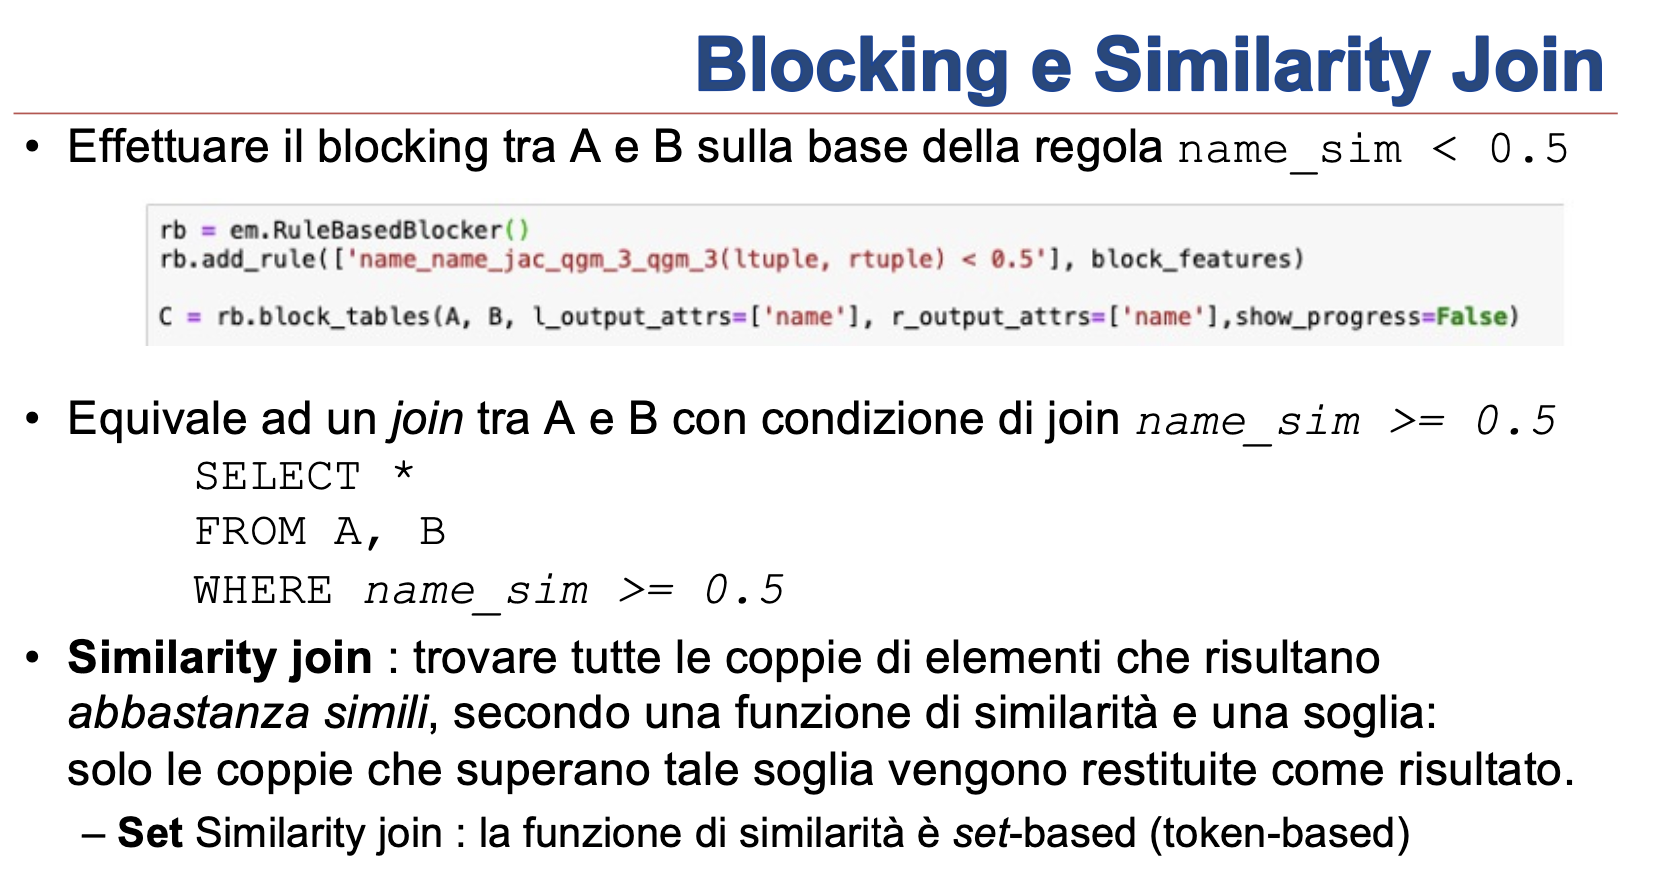

In [99]:
rb = em.RuleBasedBlocker()
rb.add_rule( ['name_name_lev_sim(ltuple, rtuple) < 0.4'], block_features)
C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=True)
ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,1924,0.989,0.9099,0.0525


In [100]:
rb = em.RuleBasedBlocker()
rb.add_rule( ['name_name_lev_sim(ltuple, rtuple) < 0.3'], block_features)
C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=True)
ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,8620,0.9509,0.9459,0.0122


In [101]:
rb = em.RuleBasedBlocker()
rb.add_rule( ['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.3'], block_features)
C = rb.block_tables(A, B, l_output_attrs=['name'], r_output_attrs=['name'],show_progress=True)
ValutaBlocking(A,B,C,GoldStandard)

Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,277,0.9984,0.9369,0.3755


In [102]:
C  = ssj.jaccard_join(A, B, 'l_id', 'r_id', 'name', 'name',  sm.QgramTokenizer(qval=3), threshold=0.3,
                                  l_out_attrs=['name' ],
                                  r_out_attrs=['name' ])
ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,277,0.9984,0.9369,0.3755


<a id="schema-agnostic-blocking"></a>
<a id="schema-agnostic-blocking"></a>
<a id="schema-agnostic-blocking"></a>
## Schema Agnostic Blocking

In [103]:
A['mix']=' '
B['mix']=' '
for x in ['name', 'addr' , 'city']:
    A['mix'] += A[x] + ' '
    B['mix'] += B[x] + ' '

A['mix'] = ''
B['mix'] = ''
for x in ['name', 'addr', 'city']:
    A['mix'] += A[x].fillna('') + ' '
    B['mix'] += B[x].fillna('') + ' '

In [104]:
C  = ssj.jaccard_join(A, B, 'l_id', 'r_id', 'mix', 'mix',  sm.QgramTokenizer(qval=3), threshold=0.3,
                                  l_out_attrs=['name', 'addr' , 'city'],
                                  r_out_attrs=['name', 'addr' , 'city'])

ValutaBlocking(A,B,C,GoldStandard)


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,532,330,2091,0.9881,0.991,0.0526


In [105]:
# Codice completo e generale per ottenere le  block_features
block_c = em.get_attr_corres(A, B)
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)
for c in A.columns:
    atypesB[c]=atypesA[c]

block_features = em.get_features(A, B,
                                 atypesA, atypesB,
                                 block_c,
                                 em.get_tokenizers_for_blocking(),
                                 em.get_sim_funs_for_blocking())
print(block_features['feature_name'].to_list())


['name_name_jac_qgm_3_qgm_3', 'name_name_cos_dlm_dc0_dlm_dc0', 'name_name_jac_dlm_dc0_dlm_dc0', 'name_name_mel', 'name_name_lev_dist', 'name_name_lev_sim', 'name_name_nmw', 'name_name_sw', 'addr_addr_jac_qgm_3_qgm_3', 'addr_addr_cos_dlm_dc0_dlm_dc0', 'addr_addr_jac_dlm_dc0_dlm_dc0', 'addr_addr_mel', 'addr_addr_lev_dist', 'addr_addr_lev_sim', 'addr_addr_nmw', 'addr_addr_sw', 'city_city_jac_qgm_3_qgm_3', 'city_city_cos_dlm_dc0_dlm_dc0', 'city_city_jac_dlm_dc0_dlm_dc0', 'city_city_mel', 'city_city_lev_dist', 'city_city_lev_sim', 'city_city_nmw', 'city_city_sw', 'phone_phone_jac_qgm_3_qgm_3', 'phone_phone_cos_dlm_dc0_dlm_dc0', 'phone_phone_jac_dlm_dc0_dlm_dc0', 'phone_phone_mel', 'phone_phone_lev_dist', 'phone_phone_lev_sim', 'phone_phone_nmw', 'phone_phone_sw', 'type_type_jac_qgm_3_qgm_3', 'type_type_cos_dlm_dc0_dlm_dc0', 'type_type_jac_dlm_dc0_dlm_dc0', 'type_type_mel', 'type_type_lev_dist', 'type_type_lev_sim', 'type_type_nmw', 'type_type_sw', 'mix_mix_jac_qgm_3_qgm_3', 'mix_mix_cos_dlm

<a id="esercizi-sul-blocking"></a>
<a id="esercizi-sul-blocking"></a>
<a id="esercizi-sul-blocking"></a>
# Esercizi sul Blocking

Si considerano le coppie di dataset, con il relativo GoldStandard e Candidate set dato,
disponibili in

http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/


L'obiettivo è realizzare un metodo di blocking
e confrontarne il risultato ottenuto con quello del Candidate Set dato (candidate_pairs.csv)

Il Candidate Set dato è stato ottenuto tramite le metodologie introdotte in questo articolo

| MatchCatcher: A Debugger for Blocking in Entity Matching, H. Li, P. Konda, P. Suganthan G.C.,
 A. Doan, B. Snyder, Y. Park, G. Krishnan, R. Deep, V. Raghavendra. EDBT-18.
 [extended version](http://pages.cs.wisc.edu/~anhai/papers1/matchcatcher-tr.pdf), [slides](http://pages.cs.wisc.edu/~anhai/papers1/matchcatcher-edbt18.pptx).




Un'altra pagina con dataset simili è:

https://sites.google.com/site/anhaidgroup/useful-stuff/the-magellan-data-repository?authuser=0




<a id="esempio-movie3-blocking"></a>
<a id="esempio-movie3-blocking"></a>
<a id="esempio-movie3-blocking"></a>
# Esempio Movie3 (Blocking)

In [149]:
A=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies3/csv/table_a.csv')
B=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies3/csv/table_b.csv')
# ed il relativo gold standard (predicted matches)
GoldStandard=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies3/csv/predicted_matches.csv')
#
CandidateSetDato=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies3/csv/candidate_pairs.csv')
A.columns.to_list(),B.columns.to_list(),GoldStandard.columns.to_list(),CandidateSetDato.columns.to_list()

(['_id', 'name', 'duration', 'genre', 'release_date', 'directors', 'stars'],
 ['_id', 'name', 'duration', 'genre', 'release_date', 'directors', 'stars'],
 ['id1', 'id2', 'conf'],
 ['id1', 'id2'])

In [150]:
# per uniformare i nomi
GoldStandard.columns=['l_id','r_id', 'conf']
CandidateSetDato.columns=['l_id','r_id']
A=A.rename(columns={'_id': 'l_id'})
B=B.rename(columns={'_id': 'r_id'})

In [151]:
# controllo che il gold standard sia coerente
pd.merge(GoldStandard,A, how='left', indicator=True).query("_merge=='left_only'"),  \
pd.merge(GoldStandard,B, how='left', indicator=True).query("_merge=='left_only'")

(Empty DataFrame
 Columns: [l_id, r_id, conf, name, duration, genre, release_date, directors, stars, _merge]
 Index: [],
 Empty DataFrame
 Columns: [l_id, r_id, conf, name, duration, genre, release_date, directors, stars, _merge]
 Index: [])

In [152]:
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')
GoldStandard['id']=range(len(GoldStandard))
cm.set_candset_properties(GoldStandard, 'id', 'l_id', 'r_id', A, B)

True

In [153]:
# si una una semplice e classica pre-elaborazione dei valori
def preprocess_value(title):
    if type(title) == str:
        title = title.lower()
        title = title.replace(',', ' ')
        title = title.replace("'", '')
        title = title.replace('&', 'and')
        title = title.replace('?', '')
        return title.strip()
    else:
        return title


for at in A.columns:
    A[at] = A[at].map(preprocess_value)
for at in B.columns:
    B[at] = B[at].map(preprocess_value)

for a in A.columns:
  A[a]=A[a].fillna(' ')

for a in B.columns:
  B[a]=B[a].fillna(' ')

In [154]:
CandidateSetDato

,l_id,r_id
0,1001,3035
1,1001,1828
2,1001,1653
3,1001,1695
4,1004,24
...,...,...
675213,105,1286
675214,2851,1476
675215,1539,627
675216,799,949


In [155]:
CandidateSetDato['id']=range(len(CandidateSetDato))
# Porta 'id' come prima colonna, serve per ValutaBlocking(A,B,CandidateSetDato,GoldStandard)
cols = ['id'] + [col for col in CandidateSetDato.columns if col != 'id']
CandidateSetDato = CandidateSetDato[cols]
CandidateSetDato.head()

,id,l_id,r_id
0,0,1001,3035
1,1,1001,1828
2,2,1001,1653
3,3,1001,1695
4,4,1004,24


<a id="domanda"></a>
<a id="domanda"></a>
<a id="domanda"></a>
### Domanda

Supponendo di aver già fatto queste valutazioni (riportate nel seguito), aggiungere altri attributi al blocking, utilizzando vari metodi, e discutere la valutazione del risultato ottenuto.

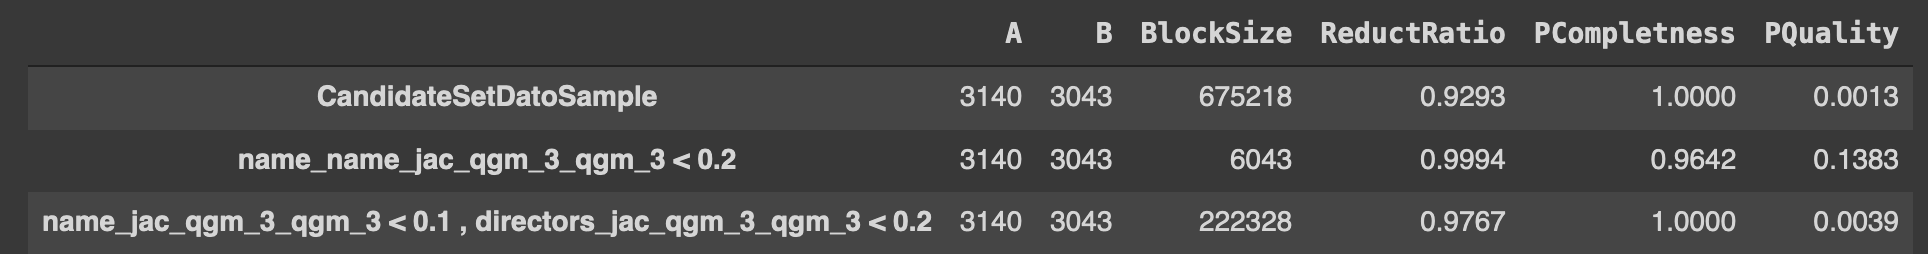






In [156]:
# Valutiamo la qualità del Candidate Set dato
ValutaBlocking(A,B,CandidateSetDato,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,675218,0.9293,1.0,0.0013


Supponendo di prendere questo come confronto, riusciamo ad effettuare un metodo di blocking con  analoga qualità?

Si noti che il Benchmark mette a disposizione il risultato finale, non il *procedimento, il codice* per ottenerlo. Inoltre in questi esempi, il blocking viene effettuando tramite un certo numero di iterazioni (#Iterations) sulla base di quanto descritto nella sezione
**Knowing When to Stop Modifying the Blockers**:
del manuale http://pradap-www.cs.wisc.edu/magellan/how-to-guide/how_to_guide_magellan.pdf.

Noi non scenderemo a questo livello di dettaglio; è possibile approfondire l'argomento tramite la tesina.











La funzione di generazione automatica **get_features_for_blocking** non genera features su *name* e su stars in quanto di tipi differenti.
In questo caso si può modificare il tipo degli attributi e generare le features manualmente. Nel seguito un semplice esempio




In [157]:
# Codice completo e generale per ottenere le  block_features
block_c = em.get_attr_corres(A, B)
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)
for c in A.columns:
    atypesB[c]=atypesA[c]

block_features = em.get_features(A, B,
                                 atypesA, atypesB,
                                 block_c,
                                 em.get_tokenizers_for_blocking(),
                                 em.get_sim_funs_for_blocking())
block_features['feature_name'].to_list()


['name_name_jac_qgm_3_qgm_3',
 'name_name_cos_dlm_dc0_dlm_dc0',
 'name_name_mel',
 'name_name_lev_dist',
 'name_name_lev_sim',
 'duration_duration_jac_qgm_3_qgm_3',
 'duration_duration_cos_dlm_dc0_dlm_dc0',
 'duration_duration_jac_dlm_dc0_dlm_dc0',
 'duration_duration_mel',
 'duration_duration_lev_dist',
 'duration_duration_lev_sim',
 'duration_duration_nmw',
 'duration_duration_sw',
 'genre_genre_jac_qgm_3_qgm_3',
 'genre_genre_cos_dlm_dc0_dlm_dc0',
 'genre_genre_jac_dlm_dc0_dlm_dc0',
 'genre_genre_mel',
 'genre_genre_lev_dist',
 'genre_genre_lev_sim',
 'genre_genre_nmw',
 'genre_genre_sw',
 'release_date_release_date_jac_qgm_3_qgm_3',
 'release_date_release_date_cos_dlm_dc0_dlm_dc0',
 'release_date_release_date_jac_dlm_dc0_dlm_dc0',
 'release_date_release_date_mel',
 'release_date_release_date_lev_dist',
 'release_date_release_date_lev_sim',
 'release_date_release_date_nmw',
 'release_date_release_date_sw',
 'directors_directors_jac_qgm_3_qgm_3',
 'directors_directors_cos_dlm_dc0_dlm

In [158]:
# output_attrs
OA=['name', 'release_date', 'directors','stars']

In [168]:
rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.2'], block_features)

C = rb.block_tables(A, B, l_output_attrs=OA,
                          r_output_attrs=OA, show_progress=True)


ValutaBlocking(A,B,C,GoldStandard) # quality bassa

Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,6043,0.9994,0.9642,0.1383


In [169]:
ValutazioneBlocking = pd.DataFrame(columns=['A', 'B', 'BlockSize', 'ReductRatio','PCompletness','PQuality'])

ValutazioneBlocking = ValutazioneBlocking.append(
  ValutaBlocking(A,B,CandidateSetDato,GoldStandard)
           ).rename(index={0: 'CandidateSetDatoSample'})
ValutazioneBlocking

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
CandidateSetDatoSample,3140,3043,675218,0.9293,1.0,0.0013


In [163]:
# per analizzare i MissedMatches  quelli che sono nel GoldStandard e non nel Candidate Set
# lo faccio esplicitamente con il join
C=C.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
MissedMatches=pd.merge(GoldStandard,
                       C,
                       how='left', 
                       indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))


31


In [164]:
MissedMatches

,l_id,r_id
66,1736,443
147,296,3033
214,952,775
244,1439,1687
262,1352,443
363,2611,488
379,2867,2204
403,3028,1107
409,906,228
418,1210,2382


In [165]:
pd.merge(pd.merge(MissedMatches,A),B, on='r_id').head()

,l_id,r_id,name_x,duration_x,genre_x,release_date_x,directors_x,stars_x,name_y,duration_y,genre_y,release_date_y,directors_y,stars_y
0,1736,443,robin hood (40th anniversary edition) (dvd + digital copy),83 min,action and adventure anime and animation,08/06/2013,wolfgang reitherman,beulah bondi larry clemmons al dempster phil harris andy devine peter ustinov dale baer d...,robin hood (1973),1h 23min,comedy romance animation adventure family,8 november 1973 (usa),wolfgang reitherman,brian bedford phil harris roger miller
1,1352,443,robin hood (40th anniversary edition) (blu-ray + dvd + digital copy),83 min,anime and animation action and adventure,08/06/2013,wolfgang reitherman,beulah bondi larry clemmons al dempster phil harris andy devine peter ustinov dale baer d...,robin hood (1973),1h 23min,comedy romance animation adventure family,8 november 1973 (usa),wolfgang reitherman,brian bedford phil harris roger miller
2,296,3033,peter pan (anniversary edition) (blu-ray + dvd + digital code),77 min,anime and animation,,clyde geronimi wilfred jackson hamilton luske,kathryn beaumont hans conried tom conway paul collins tommy luske bobby driscoll bill thom...,peter pan (1953),1h 17min,fantasy animation adventure family musical,5 february 1953 (usa),clyde geronimi wilfred jackson,bobby driscoll kathryn beaumont hans conried
3,952,775,bad moms (blu-ray + dvd + digital hd),100,comedy,12/31/2016,jon lucas scott moore,kristen bell mila kunis kathryn hahn,a bad moms christmas (2017),1h 44min,comedy adventure,1 november 2017 (usa),jon lucas scott moore,mila kunis kristen bell kathryn hahn
4,1161,775,bad moms,100,comedy,12/31/2016,jon lucas scott moore,mila kunis kristen bell kathryn hahn jay hernandez jada pinkett smith christina applegate,a bad moms christmas (2017),1h 44min,comedy adventure,1 november 2017 (usa),jon lucas scott moore,mila kunis kristen bell kathryn hahn


In [170]:
rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1'], block_features)

C = rb.block_tables(A, B, l_output_attrs=OA,
                          r_output_attrs=OA, show_progress=True)


ValutaBlocking(A,B,C,GoldStandard)

Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,194693,0.9796,0.9988,0.0044


In [171]:
ValutazioneBlocking = ValutazioneBlocking.append(
  ValutaBlocking(A,B,C,GoldStandard)
           ).rename(index={0: 'name_name_jac_qgm_3_qgm_3 < 0.1'})
ValutazioneBlocking

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
CandidateSetDatoSample,3140,3043,675218,0.9293,1.0000,0.0013
name_name_jac_qgm_3_qgm_3 < 0.1,3140,3043,194693,0.9796,0.9988,0.0044


In [ ]:
# directors_directors_jac_dlm_dc0_dlm_dc0 directors_directors_jac_qgm_3_qgm_3 directors_directors_lev_sim

In [178]:
rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1',
            'directors_directors_jac_qgm_3_qgm_3(ltuple,rtuple) < 0.1'], block_features)

C = rb.block_tables(A, B, l_output_attrs=OA,
                          r_output_attrs=OA, show_progress=True)
ValutaBlocking(A,B,C,GoldStandard)

Finding pairs with missing value...
Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,288776,0.9698,1.0,0.003


In [179]:
ValutazioneBlocking = ValutazioneBlocking.append(
  ValutaBlocking(A,B,C,GoldStandard)
           ).rename(index={0: 'name_name_jac_qgm_3_qgm_3 < 0.1 & directors_directors_jac_qgm_3_qgm_3 < 0.1'})
ValutazioneBlocking

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
CandidateSetDatoSample,3140,3043,675218,0.9293,1.0000,0.0013
name_name_jac_qgm_3_qgm_3 < 0.1,3140,3043,194693,0.9796,0.9988,0.0044
name_name_jac_qgm_3_qgm_3 < 0.1 & directors_directors_jac_qgm_3_qgm_3 < 0.1,3140,3043,288776,0.9698,1.0000,0.0030


In [125]:
# per analizzare i MissedMatches  quelli che sono nel GoldStandard e non nel Candidate Set
# lo faccio esplicitamente con il join
C=C.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
MissedMatches=pd.merge(GoldStandard,
                       C,
                       how='left', 
                       indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))


3


In [126]:
# se rendo la rule meno restrittiva
rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.25'], block_features)

C = rb.block_tables(A, B, l_output_attrs=['name', 'release_date', 'directors','stars'],
                          r_output_attrs=['name', 'release_date', 'directors','stars'], show_progress=True)

ValutaBlocking(A,B,C,GoldStandard)

Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,2637,0.9997,0.9077,0.2984


In [127]:
C=C.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
MissedMatches=pd.merge(GoldStandard,C,how='left', indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))
pd.merge(pd.merge(MissedMatches,A),B, on='r_id')

80


,l_id,r_id,name_x,duration_x,genre_x,release_date_x,directors_x,stars_x,name_y,duration_y,genre_y,release_date_y,directors_y,stars_y
0,1736,443,robin hood (40th anniversary edition) (dvd + digital copy),83 min,action and adventure anime and animation,08/06/2013,wolfgang reitherman,beulah bondi larry clemmons al dempster phil harris andy devine peter ustinov dale baer d...,robin hood (1973),1h 23min,comedy romance animation adventure family,8 november 1973 (usa),wolfgang reitherman,brian bedford phil harris roger miller
1,1352,443,robin hood (40th anniversary edition) (blu-ray + dvd + digital copy),83 min,anime and animation action and adventure,08/06/2013,wolfgang reitherman,beulah bondi larry clemmons al dempster phil harris andy devine peter ustinov dale baer d...,robin hood (1973),1h 23min,comedy romance animation adventure family,8 november 1973 (usa),wolfgang reitherman,brian bedford phil harris roger miller
2,1725,1417,sabans power rangers (4k ultra hd + blu-ray + digital hd),124 min,action,,dean israelite,dacre montgomery naomi scott rj cyler becky g ludi lin featuring bill hader with bryan cra...,power rangers (2017),2h 4min,action adventure sci-fi,24 march 2017 (usa),dean israelite,dacre montgomery naomi scott rj cyler
3,1327,1417,sabans power rangers (blu-ray + dvd + digital hd),124 min,action and adventure,,dean israelite,dacre montgomery naomi scott rj cyler becky g ludi lin featuring bill hader with bryan cra...,power rangers (2017),2h 4min,action adventure sci-fi,24 march 2017 (usa),dean israelite,dacre montgomery naomi scott rj cyler
4,1872,1740,petes dragon (35th anniversary edition) (dvd + blu-ray),88 min,anime and animation action and adventure,10/02/2012,don chaffey,jim dale shelley winters helen reddy mickey rooney red buttons cal bartlett,petes dragon (1977),2h 8min,family fantasy animation adventure comedy musical,3 november 1977 (usa),don chaffey,sean marshall helen reddy jim dale
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,419,836,the amazing spider-man 2 (dvd),142,action and adventure,08/19/2014,marc webb,marton csokas jamie foxx chris cooper denis leary dane dehaan martin sheen shailene woodle...,spider-man: into the spider-verse 2,,action animation adventure family sci-fi,,joaquim dos santos,
76,2371,836,the amazing spider-man / the amazing spider-man 2 (dvd),277 mins.,comedy,,,andrew garfield emma stone,spider-man: into the spider-verse 2,,action animation adventure family sci-fi,,joaquim dos santos,
77,1837,1310,this means war / 27 dresses / whats your number / bride wars (dvd),,comedy,09/05/2014,,kate hudson anne hathaway reese witherspoon tom hardy chris evans anna faris,this means war (2012),1h 43min,action romance comedy,17 february 2012 (usa),mcg,reese witherspoon chris pine tom hardy
78,2690,2518,above the law/under siege 1 and 2 (blu-ray/tfe/3 disc/viva) (blu-ray),302,action and adventure,01/10/2012,andrew davis,steven seagal pam grier gary busey tommy lee jones eric bogosian katherine heigl,under siege (1992),1h 43min,action thriller,9 october 1992 (usa),andrew davis,steven seagal gary busey tommy lee jones


In [128]:
# se rendo la rule meno restrittiva
rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.2'], block_features)

C = rb.block_tables(A, B, l_output_attrs=['name', 'release_date', 'directors','stars'],
                          r_output_attrs=['name', 'release_date', 'directors','stars'], show_progress=True)

ValutaBlocking(A,B,C,GoldStandard)

Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,6043,0.9994,0.9642,0.1383


In [129]:
ValutazioneBlocking = ValutazioneBlocking.append(
  ValutaBlocking(A,B,C,GoldStandard)
           ).rename(index={0: 'name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.2'})
ValutazioneBlocking

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
CandidateSetDatoSample,3140,3043,675218,0.9293,1.0000,0.0013
name_name_jac_qgm_3_qgm_3 < 0.1,3140,3043,194693,0.9796,0.9988,0.0044
"name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.2",3140,3043,6043,0.9994,0.9642,0.1383


In [130]:
# come migliorare ulteriormente ? aggiungo directors
# con  directors_directors_jac_qgm_3_qgm_3 in quanto directors_directors_lev_sim è troppo lento ...
rb = em.RuleBasedBlocker()

rb.add_rule(['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1',
                  'directors_directors_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.2'], block_features)

C = rb.block_tables(A, B, l_output_attrs=['name', 'release_date', 'directors'],
                          r_output_attrs=['name', 'release_date', 'directors'], show_progress=True)

ValutaBlocking(A,B,C,GoldStandard)

Finding pairs with missing value...
Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,222328,0.9767,1.0,0.0039


In [131]:
# Verifico che non ci siano MissedMatches
C=C.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
MissedMatches=pd.merge(GoldStandard,C,how='left', indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))
pd.merge(pd.merge(MissedMatches,A),B, on='r_id')

0


,l_id,name_x,duration_x,genre_x,release_date_x,directors_x,stars_x,r_id,name_y,duration_y,genre_y,release_date_y,directors_y,stars_y


<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta

In [132]:
# provo anche con stars, ma utilizzando la tokenizzazione a livello di parole
rb = em.RuleBasedBlocker()

rb.add_rule(['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1',
                  'stars_stars_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) < 0.4'], block_features)


C = rb.block_tables(A, B, l_output_attrs=['name', 'release_date', 'directors'],
                          r_output_attrs=['name', 'release_date', 'directors'], show_progress=True)

ValutaBlocking(A,B,C,GoldStandard)

Finding pairs with missing value...
Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,205876,0.9785,1.0,0.0042


Cambio strategia utilizzando la concatenazione di ['name', 'directors' , 'stars']

In [133]:
   
A['mix']=' '
B['mix']=' '
for x in ['name', 'directors' , 'stars']:
    A['mix'] += A[x].fillna('')  + ' '
    B['mix'] += B[x].fillna('')  + ' '

In [134]:
C  = ssj.jaccard_join(A, B, 'l_id', 'r_id', 'mix', 'mix',  sm.QgramTokenizer(qval=3), threshold=0.1,
                                  l_out_attrs=['name',  'directors' ],
                                  r_out_attrs=['name',  'directors' ])

ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,150441,0.9843,0.9919,0.0057


In [135]:
ob = em.OverlapBlocker()
C = ob.block_tables(A, B, 'mix', 'mix', word_level=True, overlap_size=3)

ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3140,3043,32401,0.9966,0.9827,0.0263


<a id="esempio-movie6-da-completare"></a>
<a id="esempio-movie6-da-completare"></a>
<a id="esempio-movie6-da-completare"></a>
## Esempio Movie6 (da completare)

Nel precedente esempio  la qualità del Candidate Set Dato era bassa e siamo riusciti a migliorarla.

In questo invece la qualità del Candidate Set Dato è molto più alta ...

In [136]:
A=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies6/csv/table_a.csv')
B=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies6/csv/table_b.csv')
# ed il relativo gold standard (predicted matches)
GoldStandard=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies6/csv/predicted_matches.csv')
#
CandidateSetDato=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies6/csv/candidate_pairs.csv')
#A.columns.to_list(),B.columns.to_list(),GoldStandard.columns.to_list(),CandidateSetDato.columns.to_list()

In [137]:
# per uniformare i nomi
GoldStandard.columns=['l_id','r_id', 'conf']
CandidateSetDato.columns=['l_id','r_id']
A=A.rename(columns={'_id': 'l_id'})
B=B.rename(columns={'_id': 'r_id'})

In [138]:
# key e foreign key
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')
GoldStandard['id']=range(len(GoldStandard))
cm.set_candset_properties(GoldStandard, 'id', 'l_id', 'r_id', A, B)


True

In [139]:
# si una una semplice e classica pre-elaborazione dei valori
def preprocess_value(title):
    if type(title) == str:
        title = title.lower()
        title = title.replace(',', ' ')
        title = title.replace("'", '')
        title = title.replace('&', 'and')
        title = title.replace('?', '')
        return title.strip()
    else:
        return title


for at in A.columns:
    A[at] = A[at].map(preprocess_value)
for at in B.columns:
    B[at] = B[at].map(preprocess_value)

for a in A.columns:
  A[a]=A[a].fillna(' ')

for a in B.columns:
  B[a]=B[a].fillna(' ')

In [140]:
# si aggiunge un id a GoldStandard
GoldStandard['id']=range(len(GoldStandard))
# e si setta come key
em.set_key(GoldStandard, 'id')
# si settano le key dei due dataset
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')
# si settano le foreign key in GS
em.set_ltable(GoldStandard, A)
em.set_rtable(GoldStandard, B)
em.set_fk_ltable(GoldStandard, 'l_id')
em.set_fk_rtable(GoldStandard, 'r_id')

True

In [141]:
# Valutiamo la qualità del Candidate Set dato
CandidateSetDato['id']=range(len(CandidateSetDato))
# Porta 'id' come prima colonna, serve per ValutaBlocking(A,B,CandidateSetDato,GoldStandard)
cols = ['id'] + [col for col in CandidateSetDato.columns if col != 'id']
CandidateSetDato = CandidateSetDato[cols]

ValutaBlocking(A,B,CandidateSetDato,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,4000,3894,3179,0.9998,1.0,0.6672


In [142]:
# Codice completo e generale per ottenere le  block_features
block_c = em.get_attr_corres(A, B)
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)
for c in A.columns:
    atypesB[c]=atypesA[c]

block_features = em.get_features(A, B,
                                 atypesA, atypesB,
                                 block_c,
                                 em.get_tokenizers_for_blocking(),
                                 em.get_sim_funs_for_blocking())
block_features['feature_name'].to_list()



Column runtime qualifies to be more than one type. 
Please explicitly set the column type like this:
A["address"] = A["address"].astype(str) 
Similarly use int, float, boolean types.


AssertionError: Column runtime qualifies to be more than one type. 
Please explicitly set the column type like this:
A["address"] = A["address"].astype(str) 
Similarly use int, float, boolean types.

<a id="domanda"></a>
### Domanda

effettuare sia l'OverlapBlocker che il similarity join utilizzando l'attributo mix dato

In [ ]:
for at in A.columns:
    A[at] = A[at].map(preprocess_value)
for at in B.columns:
    B[at] = B[at].map(preprocess_value)


for a in A.columns:
  A[a]=A[a].fillna(' ')

for a in B.columns:
  B[a]=B[a].fillna(' ')

A['mix']=' '
for x in ['title', 'directors' , 'actors']:
    A['mix'] += A[x] + ' '

B['mix']=' '
for x in ['title', 'directors' , 'actors']:
    B['mix'] += B[x] + ' '

A['YearText']=A['year'].astype(str)
B['YearText']=B['year'].astype(str)

A['mix']=' '
for x in ['title', 'directors' , 'YearText', 'actors', 'writers']:
    A['mix'] += A[x] + ' '

B['mix']=' '
for x in ['title', 'directors' , 'YearText','actors', 'writers']:
    B['mix'] += B[x] + ' '

<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta

In [ ]:
# Instantiate overlap blocker object
ob = em.OverlapBlocker()
C = ob.block_tables(A, B, 'mix', 'mix', word_level=True, overlap_size=6,
                    l_output_attrs=['title', 'year', 'directors', 'writers', 'actors'],
                    r_output_attrs=['title', 'year', 'directors', 'writers', 'actors'],
                    show_progress=False)

In [ ]:
ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,4000,3894,7178,0.9995,0.9976,0.2948



Con la Monge Elkan:

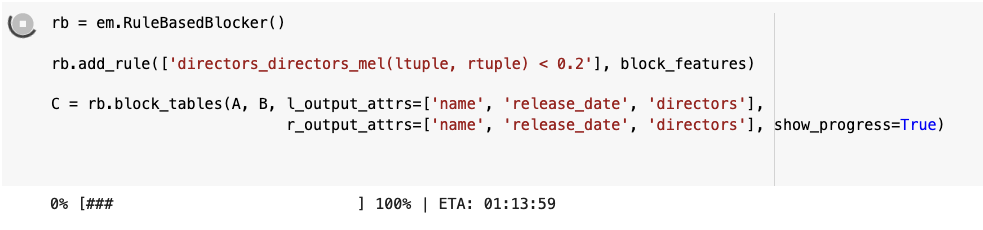




<a id="esempio-movie8-da-completare"></a>
<a id="esempio-movie8-da-completare"></a>
<a id="esempio-movie8-da-completare"></a>
## Esempio Movie8 (da completare)

In [ ]:
A=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies8/csv/table_a.csv')
B=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies8/csv/table_b.csv')
# ed il relativo gold standard (predicted matches)
GoldStandard=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies8/csv/predicted_matches.csv')
#
CandidateSetDato=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Movies8/csv/candidate_pairs.csv')
A.columns.to_list(),B.columns.to_list(),GoldStandard.columns.to_list(),CandidateSetDato.columns.to_list()

In [ ]:
# per uniformare i nomi
GoldStandard.columns=['l_id','r_id', 'conf']
CandidateSetDato.columns=['l_id','r_id']
A=A.rename(columns={'_id': 'l_id'})
B=B.rename(columns={'_id': 'r_id'})

# Valutiamo la qualità del Candidate Set dato
ValutaBlocking(A,B,CandidateSetDato[['l_id','r_id']],GoldStandard[['l_id','r_id']])

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3345,3095,2012,0.9998,1.0,0.5055


In [ ]:
for at in A.columns:
    A[at] = A[at].map(preprocess_value)
for at in B.columns:
    B[at] = B[at].map(preprocess_value)


for a in A.columns:
  A[a]=A[a].fillna(' ')

for a in B.columns:
  B[a]=B[a].fillna(' ')



A['YearText']=A['release year'].astype(str)
B['YearText']=B['release year'].astype(str)

A['mix']=' '
for x in ['title', 'director' , 'YearText', 'starring']:
    A['mix'] += A[x] + ' '

B['mix']=' '
for x in ['title', 'director' , 'YearText','starring']:
    B['mix'] += B[x] + ' '



In [ ]:
# si aggiunge un id a GoldStandard
GoldStandard['id']=range(len(GoldStandard))
# e si setta come key
em.set_key(GoldStandard, 'id')
# si settano le key dei due dataset
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')
# si settano le foreign key in GS
em.set_ltable(GoldStandard, A)
em.set_rtable(GoldStandard, B)
em.set_fk_ltable(GoldStandard, 'l_id')
em.set_fk_rtable(GoldStandard, 'r_id')

True

In [ ]:
# Instantiate overlap blocker object
ob = em.OverlapBlocker()
C_OB = ob.block_tables(A, B, 'mix', 'mix', word_level=True, overlap_size=5,
                    l_output_attrs=['title', 'director' , 'YearText','starring'],
                    r_output_attrs=['title', 'director' , 'YearText','starring'],
                    show_progress=False)

C_OB.columns
ValutaBlocking(A,B,C_OB[['ltable_l_id', 'rtable_r_id']],GoldStandard[['l_id','r_id']])

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3345,3095,2044,0.9998,0.998,0.4966


In [ ]:
2

2

<a id="esempio-cosmetics"></a>
<a id="esempio-cosmetics"></a>
<a id="esempio-cosmetics"></a>
## Esempio Cosmetics

In [181]:
A=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Cosmetics/csv/table_a.csv')
B=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Cosmetics/csv/table_b.csv')
# ed il relativo gold standard (predicted matches)
GoldStandard=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Cosmetics/csv/predicted_matches.csv')
#
CandidateSetDato=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Cosmetics/csv/candidate_pairs.csv')
A.columns.to_list(),B.columns.to_list(),GoldStandard.columns.to_list(),CandidateSetDato.columns.to_list()

(['_id', 'product name', 'brand', 'price', 'number of colors', 'rating'],
 ['_id', 'product name', 'brand', 'price', 'number of colors/scent', 'rating'],
 ['id1', 'id2', 'conf'],
 ['id1', 'id2'])

In [182]:
# per uniformare i nomi
GoldStandard.columns=['l_id','r_id', 'conf']
CandidateSetDato.columns=['l_id','r_id']
A=A.rename(columns={'_id': 'l_id'})
B=B.rename(columns={'_id': 'r_id'})

In [183]:
CandidateSetDato['id']=range(len(CandidateSetDato))
# Porta 'id' come prima colonna
cols = ['id'] + [col for col in CandidateSetDato.columns if col != 'id']
CandidateSetDato = CandidateSetDato[cols]
CandidateSetDato.head()

,id,l_id,r_id
0,0,1001,971
1,1,1001,1115
2,2,1001,928
3,3,1001,268
4,4,1001,278


In [184]:
# Valutiamo la qualità del Candidate Set dato
ValutaBlocking(A,B,CandidateSetDato,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,162226,0.9836,1.0,0.0059


In [185]:
em.get_tokenizers_for_blocking()

{'qgm_2': <function py_entitymatching.feature.tokenizers._make_tok_qgram.<locals>.tok_qgram(s)>,
 'qgm_3': <function py_entitymatching.feature.tokenizers._make_tok_qgram.<locals>.tok_qgram(s)>,
 'wspace': <function py_entitymatching.feature.tokenizers.tok_wspace(input_string)>,
 'alphabetic': <function py_entitymatching.feature.tokenizers.tok_alphabetic(input_string)>,
 'alphanumeric': <function py_entitymatching.feature.tokenizers.tok_alphanumeric(input_string)>,
 'dlm_dc0': <function py_entitymatching.feature.tokenizers._make_tok_delim.<locals>.tok_delim(s)>}

In [186]:
em.get_tokenizers_for_matching()

{'qgm_2': <function py_entitymatching.feature.tokenizers._make_tok_qgram.<locals>.tok_qgram(s)>,
 'qgm_3': <function py_entitymatching.feature.tokenizers._make_tok_qgram.<locals>.tok_qgram(s)>,
 'wspace': <function py_entitymatching.feature.tokenizers.tok_wspace(input_string)>,
 'alphabetic': <function py_entitymatching.feature.tokenizers.tok_alphabetic(input_string)>,
 'alphanumeric': <function py_entitymatching.feature.tokenizers.tok_alphanumeric(input_string)>,
 'dlm_dc0': <function py_entitymatching.feature.tokenizers._make_tok_delim.<locals>.tok_delim(s)>}

In [187]:
em.get_sim_funs_for_matching()

{'affine': <function py_entitymatching.feature.simfunctions.affine(s1, s2)>,
 'hamming_dist': <function py_entitymatching.feature.simfunctions.hamming_dist(s1, s2)>,
 'hamming_sim': <function py_entitymatching.feature.simfunctions.hamming_sim(s1, s2)>,
 'lev_dist': <function py_entitymatching.feature.simfunctions.lev_dist(s1, s2)>,
 'lev_sim': <function py_entitymatching.feature.simfunctions.lev_sim(s1, s2)>,
 'jaro': <function py_entitymatching.feature.simfunctions.jaro(s1, s2)>,
 'jaro_winkler': <function py_entitymatching.feature.simfunctions.jaro_winkler(s1, s2)>,
 'needleman_wunsch': <function py_entitymatching.feature.simfunctions.needleman_wunsch(s1, s2)>,
 'smith_waterman': <function py_entitymatching.feature.simfunctions.smith_waterman(s1, s2)>,
 'overlap_coeff': <function py_entitymatching.feature.simfunctions.overlap_coeff(arr1, arr2)>,
 'jaccard': <function py_entitymatching.feature.simfunctions.jaccard(arr1, arr2)>,
 'dice': <function py_entitymatching.feature.simfunctions

In [188]:
# Codice completo e generale per ottenere le features
block_c = em.get_attr_corres(A, B)
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)
for c in A.columns:
    atypesB[c]=atypesA[c]

block_features = em.get_features(A, B,
                                 atypesA, atypesB,
                                 block_c,
                                 em.get_tokenizers_for_blocking(),
                                 em.get_sim_funs_for_blocking())
print(block_features['feature_name'].to_list())


['product_name_product_name_jac_qgm_3_qgm_3', 'product_name_product_name_cos_dlm_dc0_dlm_dc0', 'product_name_product_name_jac_dlm_dc0_dlm_dc0', 'product_name_product_name_mel', 'product_name_product_name_lev_dist', 'product_name_product_name_lev_sim', 'product_name_product_name_nmw', 'product_name_product_name_sw', 'brand_brand_jac_qgm_3_qgm_3', 'brand_brand_cos_dlm_dc0_dlm_dc0', 'brand_brand_jac_dlm_dc0_dlm_dc0', 'brand_brand_mel', 'brand_brand_lev_dist', 'brand_brand_lev_sim', 'brand_brand_nmw', 'brand_brand_sw', 'price_price_jac_qgm_3_qgm_3', 'price_price_cos_dlm_dc0_dlm_dc0', 'price_price_jac_dlm_dc0_dlm_dc0', 'price_price_mel', 'price_price_lev_dist', 'price_price_lev_sim', 'price_price_nmw', 'price_price_sw', 'rating_rating_lev_dist', 'rating_rating_lev_sim', 'rating_rating_jar', 'rating_rating_jwn', 'rating_rating_exm', 'rating_rating_jac_qgm_3_qgm_3']


In [189]:
# si una una semplice e classica pre-elaborazione dei valori
def preprocess_value(title):
    if type(title) == str:
        title = title.lower()
        title = title.replace(',', ' ')
        title = title.replace("'", '')
        title = title.replace('&', 'and')
        title = title.replace('?', '')
        return title.strip()
    else:
        return title

for at in A.columns:
    A[at] = A[at].map(preprocess_value)
    A[at]=A[at].fillna(' ')
for at in B.columns:
    B[at] = B[at].map(preprocess_value)
    B[at]=B[at].fillna(' ')

In [190]:
# si aggiunge un id a GoldStandard
GoldStandard['id']=range(len(GoldStandard))
# e si setta come key
em.set_key(GoldStandard, 'id')
# si settano le key dei due dataset
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')
# si settano le foreign key in GS
em.set_ltable(GoldStandard, A)
em.set_rtable(GoldStandard, B)
em.set_fk_ltable(GoldStandard, 'l_id')
em.set_fk_rtable(GoldStandard, 'r_id')

True

In [191]:
# controllo che il gold standard sia coerente
pd.merge(GoldStandard,A, how='left', indicator=True).query("_merge=='left_only'"),  \
pd.merge(GoldStandard,B, how='left', indicator=True).query("_merge=='left_only'")

(Empty DataFrame
 Columns: [l_id, r_id, conf, id, product name, brand, price, number of colors, rating, _merge]
 Index: [],
 Empty DataFrame
 Columns: [l_id, r_id, conf, id, product name, brand, price, number of colors/scent, rating, _merge]
 Index: [])

In [192]:
ValutazioneBlocking = pd.DataFrame(columns=['A', 'B', 'BlockSize', 'ReductRatio','PCompletness','PQuality'])

ValutazioneBlocking = ValutazioneBlocking.append(
  ValutaBlocking(A,B,CandidateSetDato,GoldStandard)
           ).rename(index={0: 'CandidateSetDatoSample'})
ValutazioneBlocking

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
CandidateSetDatoSample,3212,3089,162226,0.9836,1.0,0.0059


In [193]:
rb = em.RuleBasedBlocker()
rb.add_rule(['product_name_product_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.3'], block_features)

C = rb.block_tables(A, B, l_output_attrs=['product name', 'brand', 'price'],
                          r_output_attrs=['product name', 'brand', 'price'], show_progress=True)
C=C.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
ValutaBlocking(A,B,C,GoldStandard)

Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,15163,0.9985,0.9633,0.0606


In [194]:
C.columns

Index(['_id', 'l_id', 'r_id', 'ltable_product name', 'ltable_brand',
       'ltable_price', 'rtable_product name', 'rtable_brand', 'rtable_price'],
      dtype='object')

In [195]:
# per analizzare quelli missing MissedMatches: quelli che sono nel GoldStandard e non nel Candidate Set
MissedMatches=pd.merge(GoldStandard,C,how='left', indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))
pd.merge(pd.merge(MissedMatches,A),B, on='r_id').head()

35


,l_id,r_id,product name_x,brand_x,price_x,number of colors,rating_x,product name_y,brand_y,price_y,number of colors/scent,rating_y
0,2450,759,dewy skin primer,cover fx,$38.00,0,4,blurring primer,cover fx,$38.00,0,4.1
1,977,759,dewy skin primer,cover fx,$38.00,0,4,blurring primer,cover fx,$38.00,0,4.1
2,28,52,photo finish foundation primer,smashbox,$15.00 - $36.00,0,4.5,the original photo finish smooth andamp; blur primer,smashbox,$36.00,0,4.5
3,1501,52,photo finish foundation primer,smashbox,$15.00 - $36.00,0,4.5,the original photo finish smooth andamp; blur primer,smashbox,$36.00,0,4.5
4,28,583,photo finish foundation primer,smashbox,$15.00 - $36.00,0,4.5,travel size photo finish pore minimizing primer,smashbox,$15.00,0,4.1


<a id="domanda"></a>
<a id="domanda"></a>
<a id="domanda"></a>
### Domanda

Mi accorgo che molte delle MissedMatches hanno un nome abbastanza diverso ma  simile  sia brand che price 

allora  al candidate set C appena calcolato devo **unire** le coppie con simile  brand and price: 

1. come definire un secondo RuleBasedBlocker ed effettuare tale  unione ?

2. è possibile farlo con un solo RuleBasedBlocker ?



<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta

Si può definire il secondo blocker come due regole semplici/predicati in OR (ad esempio)
in modo che una coppia intale blocker passa se ha entrambi brand e price con una certa similarità

In [196]:
rb = em.RuleBasedBlocker()

rb.add_rule(['brand_brand_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.8'], block_features)

rb.add_rule(['price_price_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.8'], block_features)

C2 = rb.block_tables(A, B, l_output_attrs=['product name', 'brand', 'price'],
                          r_output_attrs=['product name', 'brand', 'price'], show_progress=True)

C2=C2.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})

ValutaBlocking(A,B,C2,GoldStandard)

Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,3415,0.9997,0.695,0.1941


In [197]:
# ora posso fare l'unione insiemistica (elimino i duplicati) di C e C2
C.columns, C2.columns

(Index(['_id', 'l_id', 'r_id', 'ltable_product name', 'ltable_brand',
        'ltable_price', 'rtable_product name', 'rtable_brand', 'rtable_price'],
       dtype='object'),
 Index(['_id', 'l_id', 'r_id', 'ltable_product name', 'ltable_brand',
        'ltable_price', 'rtable_product name', 'rtable_brand', 'rtable_price'],
       dtype='object'))

In [198]:
len(C)

15163

In [199]:
len(C2)

3415

In [200]:

# per far passare sia quelle in C che in C2 ? 
# unione eliminndo i duplicati

# Unione
C_OR_C2 = pd.concat([C, C2], ignore_index=True)
len(C_OR_C2)

18578

In [201]:
#  Rimozione duplicati in base alle coppie ('l_id', 'r_id')
C_OR_C2 = C_OR_C2.drop_duplicates(subset=['l_id', 'r_id'])
len(C_OR_C2)

17722

In [202]:
ValutaBlocking(A,B,C_OR_C2,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,17722,0.9982,0.9853,0.053


In [203]:

cm.set_candset_properties(C, '_id', 'l_id', 'r_id', A, B)

cm.set_candset_properties(C2, '_id', 'l_id', 'r_id', A, B)


C1_OR_C2=em.combine_blocker_outputs_via_union([C, C2])



ValutaBlocking(A,B,C1_OR_C2,GoldStandard[['l_id','r_id']])

Foreign key for ltable is not starting with the given prefix (ltable_)
Foreign key for rtable is not starting with the given prefix (rtable_)


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,17722,0.9982,0.9853,0.053


<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta

Effettuando l'unione passano  le coppie che soddisfano):  
```
product_name_sim ≥ 0.3
OR
(brand_sim ≥ 0.8 AND price_sim ≥ 0.8)
```



per scrivere il blocker devo negare questa espressione (de morgan)

```
NOT [product_name_sim ≥ 0.3
OR (brand_sim ≥ 0.8 AND price_sim ≥ 0.8)]
≡
(product_name_sim < 0.3)
AND
(brand_sim < 0.8 OR price_sim < 0.8)
```

Che trasformo in una disjunzione di congiunzioni


```
(product_name_sim < 0.3  AND brand_sim < 0.8)
OR
(product_name_sim < 0.3 AND  price_sim < 0.8)
```



In [ ]:
rb = em.RuleBasedBlocker()
rb.add_rule(['brand_brand_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.8',
            'product_name_product_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.3'], block_features)
rb.add_rule(['price_price_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.8',
            'product_name_product_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.3'], block_features)

CC = rb.block_tables(A, B, l_output_attrs=['product name', 'brand', 'price'],
                          r_output_attrs=['product name', 'brand', 'price'], show_progress=True)


ValutaBlocking(A,B,CC,GoldStandard)

0% [##############################] 100% | ETA: 00:00:00

Finding pairs with missing value...



Total time elapsed: 00:00:00
0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:01


Finding pairs with missing value...


0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:15


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,17722,0.9982,0.9853,0.053


<a id="domanda"></a>
<a id="domanda"></a>
<a id="domanda"></a>
### Domanda
Altre modalità per effettuare Blocking sulla coppia brand e price, cioè per confrontare assieme sia brand che price dei due dataset?

<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta
Effettuare la loro concatenazione e quindi utilizzarla sia in un ruled based blocker (dopo aver generato la relativa features), oppure in un similarity join, oppure in un Overlap blocker

In [ ]:
# molto utile quando i due dataset non sono allineati come corrispondenze 1-1

A['mix']=' '
for x in ['brand', 'price' ]:
    A['mix'] += A[x] + ' '

B['mix']=' '
for x in ['brand', 'price' ]:
    B['mix'] += B[x] + ' '

In [205]:
block_c = em.get_attr_corres(A, B)
block_c['corres']

atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)

atypesA['product name']=atypesB['product name']
atypesA['rating']=atypesB['rating']


Column rating qualifies to be more than one type. 
Please explicitly set the column type like this:
A["address"] = A["address"].astype(str) 
Similarly use int, float, boolean types.


AssertionError: Column rating qualifies to be more than one type. 
Please explicitly set the column type like this:
A["address"] = A["address"].astype(str) 
Similarly use int, float, boolean types.

In [ ]:
rb = em.RuleBasedBlocker()
rb.add_rule(['product_name_product_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.25',
                  'mix_mix_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.8'], block_features)


C = rb.block_tables(A, B, l_output_attrs=['product name', 'brand', 'price'],
                          r_output_attrs=['product name', 'brand', 'price'], show_progress=True)

ValutaBlocking(A,B,C[['ltable_l_id','rtable_r_id']],GoldStandard[['l_id','r_id']])


0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:02


Finding pairs with missing value...


0% [##############################] 100% | ETA: 00:00:00

Finding pairs with missing value...



Total time elapsed: 00:00:00


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,38059,0.9962,0.9958,0.025


<a id="domanda"></a>
<a id="domanda"></a>
<a id="domanda"></a>
### Domanda
Un'altra possibile strada per combinare assieme ['brand', 'price' , 'product name' ]?

<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta
Ne effettuo la concatenazione e uso OverlapBlocker

In [ ]:
A['mix']=' '
for x in ['brand', 'price' , 'product name' ]:
    A['mix'] += A[x] + ' '

B['mix']=' '
for x in ['brand', 'price' , 'product name' ]:
    B['mix'] += B[x] + ' '

In [ ]:
# Instantiate overlap blocker object
ob = em.OverlapBlocker()
C_OB = ob.block_tables(A, B, 'mix', 'mix', word_level=True, overlap_size=2,
                    show_progress=False)

C_OB.columns
ValutaBlocking(A,B,C_OB[['ltable_l_id', 'rtable_r_id']],GoldStandard[['l_id','r_id']])

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,103682,0.9896,1.0,0.0092


In [ ]:
# quindi ottengo un risultato migliore rispetto al CandidateSetDato
ValutaBlocking(A,B,CandidateSetDato[['l_id','r_id']],GoldStandard[['l_id','r_id']])


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,162226,0.9836,1.0,0.0059


<a id="domanda"></a>
<a id="domanda"></a>
<a id="domanda"></a>
### Domanda

Come aumentare la qualità? Cosa perdo?

In [ ]:
# Instantiate overlap blocker object
ob = em.OverlapBlocker()
C_OB = ob.block_tables(A, B, 'mix', 'mix', word_level=True, overlap_size=3,
                    show_progress=False)

C_OB.columns
ValutaBlocking(A,B,C_OB[['ltable_l_id', 'rtable_r_id']],GoldStandard[['l_id','r_id']])

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,17983,0.9982,0.9979,0.0529


In [ ]:
# cosa perdo?
C=C_OB.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
MissedMatches=pd.merge(GoldStandard,C,how='left', indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))
pd.merge(pd.merge(MissedMatches,A),B, on='r_id')

2


,l_id,r_id,product name_x,brand_x,price_x,number of colors,rating_x,mix_x,product name_y,brand_y,price_y,number of colors/scent,rating_y,mix_y
0,1890,1054,velvet blurring primer - perfecting base,becca,$21.00 - $39.00,0,4,becca $21.00 - $39.00 velvet blurring primer - perfecting base,online only travel size backlight priming filter,becca,$21.00,0,4.5,becca $21.00 online only travel size backlight priming filter
1,417,1054,velvet blurring primer - perfecting base,becca,$21.00 - $39.00,0,4,becca $21.00 - $39.00 velvet blurring primer - perfecting base,online only travel size backlight priming filter,becca,$21.00,0,4.5,becca $21.00 online only travel size backlight priming filter


<a id="esempio-books4-un-goldstandard-particolare"></a>
<a id="esempio-books4-un-goldstandard-particolare"></a>
<a id="esempio-books4-un-goldstandard-particolare"></a>
## Esempio Books4: un GoldStandard *particolare*

In [ ]:
A=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Books4/csv/table_a.csv')
B=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Books4/csv/table_b.csv')
# ed il relativo gold standard (predicted matches)
GoldStandard=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Books4/csv/predicted_matches.csv')
#
CandidateSetDato=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Books4/csv/candidate_pairs.csv')
A.columns.to_list(),B.columns.to_list(),GoldStandard.columns.to_list(),CandidateSetDato.columns.to_list()

(['_id',
  'ID',
  'Name',
  'Author',
  'Format',
  'Page',
  'Language',
  'ISBN_10',
  'ISBN_13'],
 ['_id',
  'ID',
  'Name',
  'Author',
  'Format',
  'Page',
  'Language',
  'ISBN_10',
  'ISBN_13'],
 ['id1', 'id2', 'conf'],
 ['id1', 'id2'])

In [ ]:
# per uniformare i nomi
GoldStandard.columns=['l_id','r_id', 'conf']
CandidateSetDato.columns=['l_id','r_id']
A=A.rename(columns={'_id': 'l_id'})
B=B.rename(columns={'_id': 'r_id'})

In [ ]:
CandidateSetDato['id']=range(len(CandidateSetDato))
# Porta 'id' come prima colonna
cols = ['id'] + [col for col in CandidateSetDato.columns if col != 'id']
CandidateSetDato = CandidateSetDato[cols]
# Valutiamo la qualità del Candidate Set dato
ValutaBlocking(A,B,CandidateSetDato,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,7467,6385,248,1.0,1.0,0.5484


In [ ]:
print(A.columns.to_list())
print(B.columns.to_list())

['l_id', 'ID', 'Name', 'Author', 'Format', 'Page', 'Language', 'ISBN_10', 'ISBN_13']
['r_id', 'ID', 'Name', 'Author', 'Format', 'Page', 'Language', 'ISBN_10', 'ISBN_13']


In [ ]:
A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7467 entries, 0 to 7466
Data columns (total 9 columns):
l_id        7467 non-null int64
ID          7467 non-null int64
Name        7467 non-null object
Author      7467 non-null object
Format      7467 non-null object
Page        7467 non-null int64
Language    7467 non-null object
ISBN_10     7467 non-null object
ISBN_13     7467 non-null int64
dtypes: int64(4), object(5)
memory usage: 525.1+ KB


In [ ]:
B.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6385 entries, 0 to 6384
Data columns (total 9 columns):
r_id        6385 non-null int64
ID          6385 non-null int64
Name        6385 non-null object
Author      6385 non-null object
Format      6385 non-null object
Page        6385 non-null object
Language    6359 non-null object
ISBN_10     6385 non-null object
ISBN_13     6385 non-null object
dtypes: int64(2), object(7)
memory usage: 449.1+ KB


<a id="domanda"></a>
<a id="domanda"></a>
<a id="domanda"></a>
### Domanda

Quindi l'ISBN_10 e ISBN_13 sono sempre non nulli nei due dataframe:
corrispondono ad identificatori globali, cioè  valore uguale nei due dataframe  implica che sono lo stesso libro?

<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta

Si effettuano dei e si confronta il risultato con Gold Standard

In [ ]:
# si settano le key dei due dataset
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')
#
ab = em.AttrEquivalenceBlocker()
C = ab.block_tables(  A, B, # dataset
      'ISBN_10', 'ISBN_10', #
      l_output_attrs=['Name', 'Author', 'Page', 'ISBN_10'],
      r_output_attrs=['Name', 'Author', 'Page', 'ISBN_10']
    )
ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,7467,6385,135,1.0,0.9926,1.0


In [ ]:
# cosa perdo?
C=C.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
MissedMatches=pd.merge(GoldStandard,C,how='left', indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))
pd.merge(pd.merge(MissedMatches,A),B, on='r_id')

1


,l_id,r_id,ID_x,Name_x,Author_x,Format_x,Page_x,Language_x,ISBN_10_x,ISBN_13_x,ID_y,Name_y,Author_y,Format_y,Page_y,Language_y,ISBN_10_y,ISBN_13_y
0,4095,1969,4095,"Devil in Winter : The Wallflowers, Book 3",Lisa Kleypas,Paperback,374,English,006056251x,9780060562519,1970,Devil in Winter,Lisa Kleypas,Mass Market Paperback,368,English,006056251X,9780060562519


In [ ]:
# è lo stesso ISBN_10, forse c'è qualche carattere bianco in più...
# si una una semplice e classica pre-elaborazione dei valori
def preprocess_value(title):
    if type(title) == str:
        title = title.lower()
        title = title.replace(',', ' ')
        title = title.replace('.', ' ')
        title = title.replace(',', ' ')
        title = title.replace("'", '')
        title = title.replace('&', 'and')
        title = title.replace('?', '')
        return title.strip()
    else:
        return title

for at in A.columns:
    A[at] = A[at].map(preprocess_value)
    A[at]=A[at].fillna(' ')
for at in B.columns:
    B[at] = B[at].map(preprocess_value)
    B[at]=B[at].fillna(' ')

In [ ]:
# si settano le key dei due dataset
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')
#
ab = em.AttrEquivalenceBlocker()
C = ab.block_tables(  A, B, # dataset
      'ISBN_10', 'ISBN_10', #
      l_output_attrs=['Name', 'Author', 'Page', 'ISBN_10'],
      r_output_attrs=['Name', 'Author', 'Page', 'ISBN_10']
    )
ValutaBlocking(A,B,C,GoldStandard)

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,7467,6385,136,1.0,1.0,1.0


In [ ]:
# # PROVO anche ISBN_13
ab = em.AttrEquivalenceBlocker()
C = ab.block_tables(  A, B, # dataset
      'ISBN_13', 'ISBN_13', #
      l_output_attrs=['Name', 'Author', 'Page', 'ISBN_13'],
      r_output_attrs=['Name', 'Author', 'Page', 'ISBN_13']
    )
#ValutaBlocking(A,B,C,GoldStandard)

DataFrame information is not present in the catalog


KeyError: 'DataFrame information is not present in the catalog'

In [ ]:
# cosa perdo?
C=C.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
MissedMatches=pd.merge(GoldStandard,C,how='left', indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))
pd.merge(pd.merge(MissedMatches,A),B, on='r_id')

1


,l_id,r_id,ID_x,Name_x,Author_x,Format_x,Page_x,Language_x,ISBN_10_x,ISBN_13_x,ID_y,Name_y,Author_y,Format_y,Page_y,Language_y,ISBN_10_y,ISBN_13_y
0,5921,3026,5921,moonlight on nightingale way,samantha young,paperback,352,english,0349408807,9780349408804,3029,moonlight on nightingale way,samantha young,paperback,352,english,0349408807,unknown


In [ ]:
# sono di differente tipo?
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)
# si ('numeric', 'str_eq_1w')
# provo con
atypesA['ISBN_13'],atypesB['ISBN_13']
# ma non viene considerato in block_tables
# allora modifico il dataset
A['ISBN_13']=A['ISBN_13'].astype(str)

In [ ]:
# si una una semplice e classica pre-elaborazione dei valori
def preprocess_value(title):
    if type(title) == str:
        title = title.lower()
        title = title.replace(',', ' ')
        title = title.replace('.', ' ')
        title = title.replace(',', ' ')
        title = title.replace("'", '')
        title = title.replace('&', 'and')
        title = title.replace('?', '')
        return title.strip()
    else:
        return title

for at in A.columns:
    A[at] = A[at].map(preprocess_value)
    A[at]=A[at].fillna(' ')
for at in B.columns:
    B[at] = B[at].map(preprocess_value)
    B[at]=B[at].fillna(' ')

In [ ]:
# controllo che il gold standard sia coerente

pd.merge(GoldStandard,A, how='left', indicator=True).query("_merge=='left_only'"),  \
pd.merge(GoldStandard,B, how='left', indicator=True).query("_merge=='left_only'")

(Empty DataFrame
 Columns: [l_id, r_id, conf, id, ID, Name, Author, Format, Page, Language, ISBN_10, ISBN_13, _merge]
 Index: [], Empty DataFrame
 Columns: [l_id, r_id, conf, id, ID, Name, Author, Format, Page, Language, ISBN_10, ISBN_13, _merge]
 Index: [])

<a id="domanda"></a>
<a id="domanda"></a>
<a id="domanda"></a>
### Domanda

Cosa significa ReductionRatio = Completenes= Quality = 1

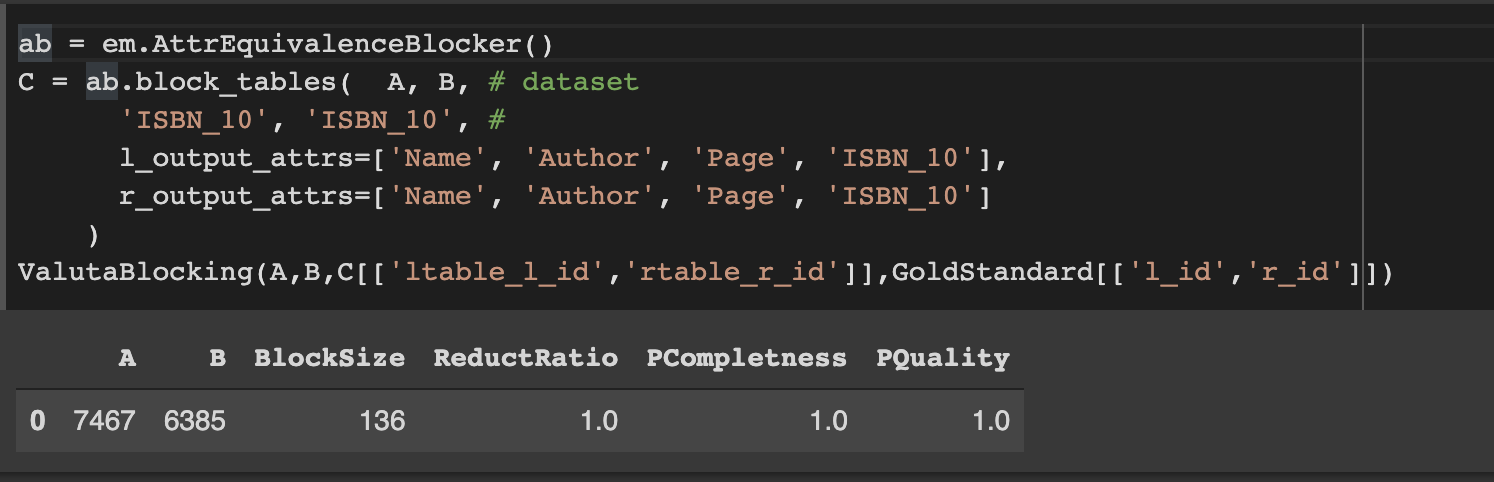

In [ ]:
ab = em.AttrEquivalenceBlocker()
C = ab.block_tables(  A, B, # dataset
      'ISBN_10', 'ISBN_10', #
      l_output_attrs=['Name', 'Author', 'Page', 'ISBN_10'],
      r_output_attrs=['Name', 'Author', 'Page', 'ISBN_10']
    )
ValutaBlocking(A,B,C[['ltable_l_id','rtable_r_id']],GoldStandard[['l_id','r_id']])

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,7467,6385,136,1.0,1.0,1.0


<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta

Il GoldStandard è stato costruito prendendo le coppie di libri con ISBN_10 uguale.


In questo caso come esercizio si può effettuare il blocking ipotizzando di non avere e quindi di non usare ISBN ...

In [ ]:
block_features = em.get_features_for_blocking(A, B, validate_inferred_attr_types=True)
block_features

The table shows the corresponding attributes along with their respective types.
Please confirm that the information  has been correctly inferred.
If you would like to skip this validation process in the future,
please set the flag validate_inferred_attr_types equal to false.


,Left Attribute,Right Attribute,Left Attribute Type,Right Attribute Type,Example Features
0,ID,ID,numeric,numeric,Exact Match; Absolute Norm
1,Name,Name,medium string (5 words to 10 words),short string (1 word to 5 words),Not Applicable: Types do not match
2,Author,Author,short string (1 word to 5 words),short string (1 word to 5 words),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"
3,Format,Format,short string (1 word to 5 words),short string (1 word to 5 words),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"
4,Page,Page,numeric,short string (1 word),Not Applicable: Types do not match
5,Language,Language,short string (1 word to 5 words),short string (1 word to 5 words),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"
6,ISBN_10,ISBN_10,short string (1 word),short string (1 word),Levenshtein Distance; Levenshtein Similarity
7,ISBN_13,ISBN_13,short string (1 word),short string (1 word),Levenshtein Distance; Levenshtein Similarity


Do you want to proceed? (y/n):n

If the attribute correspondences or types have been inferred incorrectly,
use the get_features() function with your  own correspondences and attribute
types to get the correct features for your data


In [ ]:
block_c = em.get_attr_corres(A, B)
block_c['corres']

[('ID', 'ID'),
 ('Name', 'Name'),
 ('Author', 'Author'),
 ('Format', 'Format'),
 ('Page', 'Page'),
 ('Language', 'Language'),
 ('ISBN_10', 'ISBN_10'),
 ('ISBN_13', 'ISBN_13')]

In [ ]:
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)
atypesB['Name']=atypesA['Name']
atypesA['Page']=atypesB['Page']


In [ ]:
block_features = em.get_features(A, B,
                                 atypesA, atypesB, block_c,
                                 em.get_tokenizers_for_blocking(), em.get_sim_funs_for_blocking())
block_features['feature_name'].to_list()

['ID_ID_exm',
 'ID_ID_anm',
 'ID_ID_lev_dist',
 'ID_ID_lev_sim',
 'Name_Name_jac_qgm_3_qgm_3',
 'Name_Name_cos_dlm_dc0_dlm_dc0',
 'Name_Name_mel',
 'Name_Name_lev_dist',
 'Name_Name_lev_sim',
 'Author_Author_jac_qgm_3_qgm_3',
 'Author_Author_cos_dlm_dc0_dlm_dc0',
 'Author_Author_jac_dlm_dc0_dlm_dc0',
 'Author_Author_mel',
 'Author_Author_lev_dist',
 'Author_Author_lev_sim',
 'Author_Author_nmw',
 'Author_Author_sw',
 'Format_Format_jac_qgm_3_qgm_3',
 'Format_Format_cos_dlm_dc0_dlm_dc0',
 'Format_Format_jac_dlm_dc0_dlm_dc0',
 'Format_Format_mel',
 'Format_Format_lev_dist',
 'Format_Format_lev_sim',
 'Format_Format_nmw',
 'Format_Format_sw',
 'Page_Page_lev_dist',
 'Page_Page_lev_sim',
 'Page_Page_jar',
 'Page_Page_jwn',
 'Page_Page_exm',
 'Page_Page_jac_qgm_3_qgm_3',
 'Language_Language_jac_qgm_3_qgm_3',
 'Language_Language_cos_dlm_dc0_dlm_dc0',
 'Language_Language_jac_dlm_dc0_dlm_dc0',
 'Language_Language_mel',
 'Language_Language_lev_dist',
 'Language_Language_lev_sim',
 'Language_Lan

<a id="nota-su-exm-exact-match"></a>
<a id="nota-su-exm-exact-match"></a>
<a id="nota-su-exm-exact-match"></a>
### Nota su exm (exact match)

Proviamo la feature ISBN_10_ISBN_10_exm tramite

> rb.add_rule(['ISBN_10_ISBN_10_exm(ltuple, rtuple) == 0'], block_features)

Effettuiamo la prova su un subset in quanto sui dataset completi l'esecuzione dopo 3 minuti non era ancora terminata


In [ ]:
# consideriamo un sottoinsieme
Asample=A.sample(700)
Bsample=B.sample(700)

# si settano le key dei due dataset
em.set_key(Asample, 'l_id')
em.set_key(Bsample, 'r_id')

True

In [ ]:
ab = em.AttrEquivalenceBlocker()
C = ab.block_tables(  Asample, Bsample, # dataset
      'ISBN_10', 'ISBN_10', #
      l_output_attrs=['Name', 'Author', 'Page', 'ISBN_10'],
      r_output_attrs=['Name', 'Author', 'Page', 'ISBN_10']
    )
C.head()

,_id,ltable_l_id,rtable_r_id,ltable_Name,ltable_Author,ltable_Page,ltable_ISBN_10,rtable_Name,rtable_Author,rtable_Page,rtable_ISBN_10
0,0,4545,804,the proposal,jasmine guillory,352,0399587683,the proposal,jasmine guillory,327,0399587683


In [ ]:
rb = em.RuleBasedBlocker()
rb.add_rule(['ISBN_10_ISBN_10_exm(ltuple, rtuple) == 0'], block_features)


C = rb.block_tables(Asample, Bsample, l_output_attrs=['Name', 'Author', 'Page', 'ISBN_10'],
                          r_output_attrs=['Name', 'Author', 'Page', 'ISBN_10'], show_progress=True)

C.head()

0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:08


,_id,ltable_l_id,rtable_r_id,ltable_Name,ltable_Author,ltable_Page,ltable_ISBN_10,rtable_Name,rtable_Author,rtable_Page,rtable_ISBN_10
0,0,4545,804,the proposal,jasmine guillory,352,0399587683,the proposal,jasmine guillory,327,0399587683


<a id="esempio-abtbuy-con-valori-nulli-senza-candidate-set-dato"></a>
<a id="esempio-abtbuy-con-valori-nulli-senza-candidate-set-dato"></a>
<a id="esempio-abtbuy-con-valori-nulli-senza-candidate-set-dato"></a>
# Esempio AbtBuy (con valori nulli, senza Candidate Set dato)

In [ ]:
A = pd.read_csv('./sample_data/Abt.csv', dtype=str, sep=',' ,encoding="ISO-8859-1")
B = pd.read_csv('./sample_data/Buy.csv', dtype=str, sep=',',encoding="ISO-8859-1")
GoldStandard = pd.read_csv('./sample_data/abt_buy_perfectMapping.csv', dtype=str, sep=',' ,encoding="ISO-8859-1")

A.rename(columns={'id':'l_id'}, inplace=True)
B.rename(columns={'id':'r_id'}, inplace=True)
GoldStandard.rename(columns={'idAbt':'l_id'}, inplace=True)
GoldStandard.rename(columns={'idBuy':'r_id'}, inplace=True)

# si aggiunge un id a GoldStandard
GoldStandard['id']=range(len(GoldStandard))
# e si setta come key
em.set_key(GoldStandard, 'id')
# si settano le key dei due dataset
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')
# si settano le foreign key in GS
em.set_ltable(GoldStandard, A)
em.set_rtable(GoldStandard, B)
em.set_fk_ltable(GoldStandard, 'l_id')
em.set_fk_rtable(GoldStandard, 'r_id')

A.columns.to_list(),B.columns.to_list(),GoldStandard.columns.to_list()

(['l_id', 'name', 'description', 'price'],
 ['r_id', 'name', 'description', 'manufacturer', 'price'],
 ['l_id', 'r_id', 'id'])

In [ ]:
B.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   r_id          1092 non-null   object
 1   name          1092 non-null   object
 2   description   651 non-null    object
 3   manufacturer  1086 non-null   object
 4   price         590 non-null    object
dtypes: object(5)
memory usage: 42.8+ KB


In [ ]:
GoldStandard.shape, GoldStandard.sample()

((1097, 3),       l_id       r_id   id
 398  34258  206888011  398)

In [ ]:
block_features = em.get_features_for_blocking(A, B, validate_inferred_attr_types=True)

The table shows the corresponding attributes along with their respective types.
Please confirm that the information  has been correctly inferred.
If you would like to skip this validation process in the future,
please set the flag validate_inferred_attr_types equal to false.


,Left Attribute,Right Attribute,Left Attribute Type,Right Attribute Type,Example Features
0,name,name,medium string (5 words to 10 words),medium string (5 words to 10 words),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"
1,description,description,short string (1 word),short string (1 word),"Jaccard Similarity [3-grams, 3-grams]; Cosine Similarity [Space Delimiter, Space Delimiter]"
2,price,price,short string (1 word),short string (1 word),Levenshtein Distance; Levenshtein Similarity


Do you want to proceed? (y/n):n

If the attribute correspondences or types have been inferred incorrectly,
use the get_features() function with your  own correspondences and attribute
types to get the correct features for your data


In [ ]:
block_c = em.get_attr_corres(A, B)
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)

atypesA['description']=atypesB['description']


block_features = em.get_features(A, B,
                                 atypesA, atypesB, block_c,
                                 em.get_tokenizers_for_blocking(), em.get_sim_funs_for_blocking())
block_features['feature_name'].to_list()

['name_name_jac_qgm_3_qgm_3',
 'name_name_cos_dlm_dc0_dlm_dc0',
 'name_name_mel',
 'name_name_lev_dist',
 'name_name_lev_sim',
 'description_description_jac_qgm_3_qgm_3',
 'description_description_cos_dlm_dc0_dlm_dc0',
 'price_price_lev_dist',
 'price_price_lev_sim',
 'price_price_jar',
 'price_price_jwn',
 'price_price_exm',
 'price_price_jac_qgm_3_qgm_3']

In [ ]:
rb = em.RuleBasedBlocker()
rb.add_rule(['description_description_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1'], block_features)

C = rb.block_tables(A, B, l_output_attrs=['name', 'description', 'price'],
                          r_output_attrs=['name', 'description', 'price'], show_progress=True)

ValutaBlocking(A,B,C[['ltable_l_id','rtable_r_id']],GoldStandard[['l_id','r_id']])

0% [##############################] 100% | ETA: 00:00:00

Finding pairs with missing value...



Total time elapsed: 00:00:00
0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:01


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,1081,1092,484415,0.5896,0.6317,0.0014


In [ ]:
 C[C['ltable_description'].isnull()].shape,C[C['rtable_description'].isnull()].shape

((0, 9), (476721, 9))

In [ ]:
for at in A.columns:
    A[at] = A[at].map(preprocess_value)
    A[at]=A[at].fillna(' ')
for at in B.columns:
    B[at] = B[at].map(preprocess_value)
    B[at]=B[at].fillna(' ')

In [ ]:
block_features = em.get_features(A, B,
                                 atypesA, atypesB, block_c,
                                 em.get_tokenizers_for_blocking(), em.get_sim_funs_for_blocking())
block_features['feature_name'].to_list()

['name_name_jac_qgm_3_qgm_3',
 'name_name_cos_dlm_dc0_dlm_dc0',
 'name_name_mel',
 'name_name_lev_dist',
 'name_name_lev_sim',
 'description_description_jac_qgm_3_qgm_3',
 'description_description_cos_dlm_dc0_dlm_dc0',
 'price_price_lev_dist',
 'price_price_lev_sim',
 'price_price_jar',
 'price_price_jwn',
 'price_price_exm',
 'price_price_jac_qgm_3_qgm_3']

In [ ]:
rb = em.RuleBasedBlocker()
rb.add_rule(['description_description_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.1'], block_features)

C = rb.block_tables(A, B, l_output_attrs=['name', 'description', 'price'],
                          r_output_attrs=['name', 'description', 'price'], show_progress=True)

ValutaBlocking(A,B,C[['ltable_l_id','rtable_r_id']],GoldStandard[['l_id','r_id']])

0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00


Finding pairs with missing value...


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,1081,1092,10703,0.9909,0.2479,0.0254


In [ ]:
 C[C['ltable_description'].isnull()].shape,C[C['rtable_description'].isnull()].shape

((0, 9), (0, 9))

In [ ]:
 C[C.ltable_description==' '].shape, C[C.rtable_description==' '].shape,

((0, 9), (0, 9))

<a id="domanda"></a>
<a id="domanda"></a>
<a id="domanda"></a>
## Domanda:

valutare alcuni metodi di blocking con Completeness maggioree del 90%

In [ ]:
ValutazioneBlocking = pd.DataFrame(columns=['A', 'B', 'BlockSize', 'ReductRatio','PCompletness','PQuality'])

In [ ]:

rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.2'], block_features)


rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) < 0.25'], block_features)


C = rb.block_tables(A, B,  show_progress=True)

ValutaBlocking(A,B,C[['ltable_l_id','rtable_r_id']],GoldStandard[['l_id','r_id']])



0% [##############################] 100% | ETA: 00:00:00

Finding pairs with missing value...



Total time elapsed: 00:00:00


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,1081,1092,19002,0.9839,0.9544,0.0551


In [ ]:
ob = em.OverlapBlocker()
C = ob.block_tables(A, B, 'name', 'name', word_level=True, overlap_size=2,
                    show_progress=False)

ValutaBlocking(A,B,C[['ltable_l_id', 'rtable_r_id']],GoldStandard[['l_id','r_id']])

In [ ]:
ValutazioneBlocking = ValutazioneBlocking.append(
  ValutaBlocking(A,B,C[['ltable_l_id','rtable_r_id']],GoldStandard[['l_id','r_id']])
           ).rename(index={0: ' OverlapBlocker name, word_level=True, overlap_size=2'})
ValutazioneBlocking

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
name_name_jac_qgm_3_qgm_3 <0.2,1081,1092,10548,0.9911,0.9426,0.0980
name_name_cos_dlm_dc0_dlm_dc0 < 0.2,1081,1092,30204,0.9744,0.9654,0.0351
"OverlapBlocker name, word_level=True, overlap_size=2",1081,1092,36379,0.9692,0.9681,0.0292


In [ ]:
C=C.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
MissedMatches=pd.merge(GoldStandard,C,how='left', indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))
pd.merge(pd.merge(MissedMatches,A),B, on='r_id')

38


,l_id,r_id,name_x,description_x,price_x,mix_x,name_y,description_y,manufacturer,price_y,mix_y
0,6284,202812567,bose 27028 161 bookshelf pair speakers in white 161wh,bose 161 bookshelf speakers in white 161wh/ articulated array speaker design/ high excursion t...,$158 00,bose 27028 161 bookshelf pair speakers in white 161wh bose 161 bookshelf speakers in white ...,boss 161 speaker,speaker magnetically shielded,bose,$158 00,boss 161 speaker speaker magnetically shielded
1,9355,203151776,cuisinart convection oven toaster broiler with exact heat sensor tob165wh,cuisinart convection oven toaster broiler with exact heat sensor tob165wh/ 0 5 cubic foot oven...,$149 00,cuisinart convection oven toaster broiler with exact heat sensor tob165wh cuisinart convectio...,white 5 cu ft 1500 watt convection/broiler/toaster oven,,cuisinart,$149 00,white 5 cu ft 1500 watt convection/broiler/toaster oven
2,34125,203165921,belkin cush top for computer laptop f8n044org,belkin cush top for computer laptop f8n044org/ uniquely designed soft material for comfortable...,,belkin cush top for computer laptop f8n044org belkin cush top for computer laptop f8n044org...,belkin cushtop f8n044 org,orange,belkin,,belkin cushtop f8n044 org orange
3,34127,203165922,belkin cush top for computer laptop f8n044grn,belkin cush top for computer laptop f8n044grn/ uniquely designed soft material for comfortable...,,belkin cush top for computer laptop f8n044grn belkin cush top for computer laptop f8n044grn...,belkin cushtop f8n044 grn,green,belkin,,belkin cushtop f8n044 grn green
4,34126,203166120,belkin cush top for computer laptop f8n044slv,belkin cush top for computer laptop f8n044slv/ uniquely designed soft material for comfortable...,,belkin cush top for computer laptop f8n044slv belkin cush top for computer laptop f8n044slv...,belkin cushtop f8n044 slv,silver,belkin,,belkin cushtop f8n044 slv silver
5,22242,203198950,cuisinart programmable coffeemaker stainless steel finish dcc2000,cuisinart 12 cup programmable coffeemaker dcc2000/ fully programmable/ removable coffee reserv...,$100 00,cuisinart programmable coffeemaker stainless steel finish dcc2000 cuisinart 12 cup programm...,dcc 2000 coffee maker (12 cup stainless steel),,cuisinart,$99 95,dcc 2000 coffee maker (12 cup stainless steel)
6,23965,203322272,panasonic all in one flatbed laser fax kxflb801,panasonic all in one flatbed laser fax kxflb801/ high speed laser printing/ multi function usb...,,panasonic all in one flatbed laser fax kxflb801 panasonic all in one flatbed laser fax kxfl...,panasonic kx flb801 multifunction printer kx flb801,panasonic all in one all in one flatbed laser fax,panasonic,,panasonic kx flb801 multifunction printer kx flb801 panasonic all in one all in one flatbed l...
7,27729,203379250,lg wm0642hw 4 0 cu ft white rear control washer wm0642hwh,lg wm0642hw white rear control washer wm0642hwh/ 4 0 cu ft capacity/ 7 washing programs/ 6 t...,,lg wm0642hw 4 0 cu ft white rear control washer wm0642hwh lg wm0642hw white rear control wash...,lg electronics wm0642hw front load washing machine with 7 washing programs,,lg electronics,,lg electronics wm0642hw front load washing machine with 7 washing programs
8,29339,203888987,panasonic silver rice cooker/warmer srtmb10,panasonic silver rice cooker/warmer srtmb10/ 6 menu settings/ non stick coated pan/ 13 hour pr...,,panasonic silver rice cooker/warmer srtmb10 panasonic silver rice cooker/warmer srtmb10/ 6 ...,panasonic srtmb10/rice cooker/5 5cup/fuzzy sr tmb10,,panasonic,,panasonic srtmb10/rice cooker/5 5cup/fuzzy sr tmb10
9,23864,204636071,hoover bagged tempo widepath upright vacuum u5140,hoover u5140 900 bagged tempo widepath upright vacuum u5140/ filter traps 100 percent dust mit...,,hoover bagged tempo widepath upright vacuum u5140 hoover u5140 900 bagged tempo widepath upri...,hoover company #u5140900 wide path bag up vac,,hoover company,,hoover company #u5140900 wide path bag up vac


In [ ]:
A['mix']=' '
for x in ['name', 'description'  ]:
    A['mix'] += A[x] + ' '

B['mix']=' '
for x in ['name', 'description'  ]:
    B['mix'] += B[x] + ' '

In [ ]:
ob = em.OverlapBlocker()
C = ob.block_tables(A, B, 'mix', 'mix', word_level=True, overlap_size=4,
                    show_progress=False)

ValutaBlocking(A,B,C[['ltable_l_id', 'rtable_r_id']],GoldStandard[['l_id','r_id']])

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,1081,1092,35669,0.9698,0.8952,0.0275


In [ ]:
block_c = em.get_attr_corres(A, B)
atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)

atypesA['description']=atypesB['description']


block_features = em.get_features(A, B,
                                 atypesA, atypesB, block_c,
                                 em.get_tokenizers_for_blocking(), em.get_sim_funs_for_blocking())
block_features['feature_name'].to_list()

['name_name_jac_qgm_3_qgm_3',
 'name_name_cos_dlm_dc0_dlm_dc0',
 'name_name_mel',
 'name_name_lev_dist',
 'name_name_lev_sim',
 'description_description_jac_qgm_3_qgm_3',
 'description_description_cos_dlm_dc0_dlm_dc0',
 'description_description_mel',
 'description_description_lev_dist',
 'description_description_lev_sim',
 'price_price_jac_qgm_3_qgm_3',
 'price_price_cos_dlm_dc0_dlm_dc0',
 'price_price_jac_dlm_dc0_dlm_dc0',
 'price_price_mel',
 'price_price_lev_dist',
 'price_price_lev_sim',
 'price_price_nmw',
 'price_price_sw',
 'mix_mix_jac_qgm_3_qgm_3',
 'mix_mix_cos_dlm_dc0_dlm_dc0']

In [ ]:
rb = em.RuleBasedBlocker()
rb.add_rule(['mix_mix_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) < 0.2'], block_features)

C = rb.block_tables(A, B,              l_output_attrs=['name', 'description','mix'],
                          r_output_attrs=['name', 'description','mix'],
show_progress=True)


ValutaBlocking(A,B,C[['ltable_l_id','rtable_r_id']],GoldStandard[['l_id','r_id']])

0% [##############################] 100% | ETA: 00:00:00

Finding pairs with missing value...



Total time elapsed: 00:00:00


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,1081,1092,13866,0.9883,0.8979,0.071


In [ ]:
C=C.rename(columns={'ltable_l_id': 'l_id', 'rtable_r_id': 'r_id'})
MissedMatches=pd.merge(GoldStandard,C,how='left', indicator=True).query("_merge=='left_only'")[['l_id','r_id']]
print(len(MissedMatches))
pd.merge(pd.merge(MissedMatches,A),B, on='r_id').query("description_x==' ' ")

590


,l_id,r_id,name_x,description_x,price_x,mix_x,name_y,description_y,manufacturer,price_y,mix_y


In [ ]:
rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_jac_qgm_3_qgm_3(ltuple, rtuple) < 0.3'], block_features)
rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) < 0.3'], block_features)
rb = em.RuleBasedBlocker()
rb.add_rule(['name_name_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) < 0.3',
         'description_description_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) < 0.4'], block_features)

C = rb.block_tables(A, B,  show_progress=True)

ValutaBlocking(A,B,C[['ltable_l_id','rtable_r_id']],GoldStandard[['l_id','r_id']])

0% [##############################] 100% | ETA: 00:00:00

Finding pairs with missing value...



Total time elapsed: 00:00:00
0% [##############################] 100% | ETA: 00:00:00

Finding pairs with missing value...



Total time elapsed: 00:00:00
0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:01


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,1081,1092,496758,0.5792,0.9772,0.0022


In [ ]:
# Calcolo esplicitamente la similarità usata nella rule tramite una funzione
# è importante conosce il nome delle colonne della MT
MT.columns

Index(['l_id', 'r_id', 'id', 'l_title', 'l_year', 'l_genres', 'l_language',
       'l_runtime', 'l_budget', 'l_revenue', 'l_directors', 'l_writers',
       'l_actors', 'r_title', 'r_year', 'r_genres', 'r_language', 'r_runtime',
       'r_budget', 'r_revenue', 'r_directors', 'r_writers', 'r_actors',
       'pred_label'],
      dtype='object')

In [ ]:
# Rule : title_title_lev_sim(ltuple, rtuple) > 0.6
def FunzioneSimilarità(x):
    lev = sm.Levenshtein()
    return lev.get_sim_score(x['l_title'],x['r_title'])

MT['sim']=MT.apply(FunzioneSimilarità, axis=1)
MT.sort_values('sim').head()

,l_id,r_id,id,l_title,l_year,l_genres,l_language,l_runtime,l_budget,l_revenue,...,r_genres,r_language,r_runtime,r_budget,r_revenue,r_directors,r_writers,r_actors,pred_label,sim
2177,1726,2268,2177,Peter Pan 2: Return to Never Land,2002,Animation;Adventure;Family;Fantasy,English,72.0,20000000,109862682.0,...,Adventure;Fantasy;Animation;Family,English,72,20000000.0,109862682.0,Donovan Cook;Robin Budd;David J. Hardy,Temple Mathews,Harriet Owen;Blayne Weaver;Jeff Bennett;Kath Soucie;Corey Burton;Corey Burton;Andrew McDonough;R...,1,0.606061
1170,1482,1174,1170,The Curse of the Were-Rabbit,2005,Animation;Adventure;Comedy;Family;Fantasy;Mystery;Sci-Fi,English,85.0,30000000,192610372.0,...,Adventure;Animation;Comedy;Family,English,85,30000000.0,192452832.0,Nick Park;Steve Box;Penny Foster;Marnie Paxton;Richard Beek;Lisa Butler;Merlin Crossingham;Vinny...,Nick Park;Mark Burton;Steve Box;Bob Baker;Robert Stevenhagen,Peter Sallis;Helena Bonham Carter;Ralph Fiennes;Nicholas Smith;Liz Smith;John Thomson;Vincent Eb...,1,0.608696
2293,2140,1679,2293,The Karate Kid Part III,1989,Action;Drama;Family;Sport,English,112.0,NaN,NaN,...,Drama,English,126,8000000.0,90815558.0,John G. Avildsen;Alvin Greenman,Robert Mark Kamen,Ralph Macchio;Pat Morita;Elisabeth Shue;Martin Kove;Randee Heller;William Zabka;Chad McQueen;Ron...,1,0.608696
64,1184,683,64,Insidious: The Last Key,2018,Horror;Mystery;Thriller,English,103.0,10000000,144575300.0,...,Horror;Thriller,English,106,5000000.0,NaN,James Wan,Leigh Whannell;James Wan,Patrick Wilson;Rose Byrne;Ty Simpkins;Lin Shaye;Barbara Hershey;Steve Coulter;Leigh Whannell;Ang...,1,0.608696
3119,806,3148,3119,The Karate Kid,1984,Action;Drama;Family;Sport,English,126.0,8000000,NaN,...,Adventure;Drama;Action;Romance;Family,English,113,113.0,115103979.0,John G. Avildsen,Robert Mark Kamen,Ralph Macchio;Pat Morita;Nobu McCarthy;Tamlyn Tomita;Yuji Okumoto;Joey Miyashima;Marc Hayashi;Da...,1,0.608696


In [ ]:
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

<a id="esempio-cosmetics"></a>
<a id="esempio-cosmetics"></a>
<a id="esempio-cosmetics"></a>
# Esempio Cosmetics

In [ ]:
A=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Cosmetics/csv/table_a.csv')
B=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Cosmetics/csv/table_b.csv')
# ed il relativo gold standard (predicted matches)
GoldStandard=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Cosmetics/csv/predicted_matches.csv')
#
CandidateSetDato=pd.read_csv('http://pages.cs.wisc.edu/~anhai/data/wisc_em_benchmark/839_spring19/Cosmetics/csv/candidate_pairs.csv')
A.columns.to_list(),B.columns.to_list(),GoldStandard.columns.to_list(),CandidateSetDato.columns.to_list()

(['_id', 'product name', 'brand', 'price', 'number of colors', 'rating'],
 ['_id', 'product name', 'brand', 'price', 'number of colors/scent', 'rating'],
 ['id1', 'id2', 'conf'],
 ['id1', 'id2'])

In [ ]:
# per uniformare i nomi
GoldStandard.columns=['l_id','r_id', 'conf']
CandidateSetDato.columns=['l_id','r_id']
A=A.rename(columns={'_id': 'l_id'})
B=B.rename(columns={'_id': 'r_id'})

# si settano le key dei due dataset
em.set_key(A, 'l_id')
em.set_key(B, 'r_id')

GoldStandard['id']=range(len(GoldStandard))
CandidateSetDato['id']=range(len(CandidateSetDato))

cm.set_candset_properties(GoldStandard, 'id', 'l_id', 'r_id', A, B)
cm.set_candset_properties(CandidateSetDato, 'id', 'l_id', 'r_id', A, B)

True

In [ ]:
# si una una semplice e classica pre-elaborazione dei valori
def preprocess_value(title):
    if type(title) == str:
        title = title.lower()
        title = title.replace(',', ' ')
        title = title.replace('-', ' ')
        title = title.replace(';', ' ')
        title = title.replace("'", '')
        title = title.replace('&', 'and')
        title = title.replace('?', '')
        return title.strip()
    else:
        return title

for at in A.columns:
    A[at] = A[at].map(preprocess_value)
    A[at]=A[at].fillna(' ')
for at in B.columns:
    B[at] = B[at].map(preprocess_value)
    B[at]=B[at].fillna(' ')

<a id="domanda-blocking"></a>
<a id="domanda-blocking"></a>
<a id="domanda-blocking"></a>
## Domanda (Blocking)

Effettuare il blocking (e confrontarne il risultato rispetto al CandidateSetDato) tramite similarity join sul seguente attributo mix:

In [ ]:
A['mix']=' '
for x in ['brand', 'price' , 'product name' ]:
    A['mix'] += A[x] + ' '

B['mix']=' '
for x in ['brand', 'price' , 'product name' ]:
    B['mix'] += B[x] + ' '

<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta

In [ ]:
C_SIMJOIN_JAC  = ssj.jaccard_join(A, B, 'l_id', 'r_id',
                                  'mix', 'mix',  sm.QgramTokenizer(qval=3), threshold=0.5,
                                  l_out_attrs=['product name', 'brand', 'price', 'rating'],
                                  r_out_attrs=['product name', 'brand', 'price',  'rating'])

C_SIMJOIN_JAC=C_SIMJOIN_JAC.rename(columns={'l_l_id': 'l_id'})
C_SIMJOIN_JAC=C_SIMJOIN_JAC.rename(columns={'r_r_id': 'r_id'})

ValutaBlocking(A,B,C_SIMJOIN_JAC[['l_id','r_id']],GoldStandard[['l_id','r_id']])

0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:01


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,1648,0.9998,0.9423,0.5455


In [ ]:
ValutaBlocking(A,B,CandidateSetDato[['l_id','r_id']],GoldStandard[['l_id','r_id']])

,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,162226,0.9836,1.0,0.0059


In [ ]:
Valuta(GoldStandard[['l_id','r_id']],C_SIMJOIN_JAC[['l_id','r_id']])

,MT,TP,FP,FN,P,R,F
0,1648,899,749,55,0.5455,0.9423,0.691


In [ ]:
Valuta(GoldStandard[['l_id','r_id']],CandidateSetDato[['l_id','r_id']])

,MT,TP,FP,FN,P,R,F
0,162226,954,161272,0,0.0059,1.0,0.0117


In [ ]:
# con alcuni tentativi si riesce ad individuare la soglia per ottenere Recall pari a 1
C_SIMJOIN_JAC  = ssj.jaccard_join(A, B, 'l_id', 'r_id',
                                  'mix', 'mix',  sm.QgramTokenizer(qval=3), threshold=0.22,
                                  l_out_attrs=['product name', 'brand', 'price', 'rating'],
                                  r_out_attrs=['product name', 'brand', 'price',  'rating'])

C_SIMJOIN_JAC=C_SIMJOIN_JAC.rename(columns={'l_l_id': 'l_id'})
C_SIMJOIN_JAC=C_SIMJOIN_JAC.rename(columns={'r_r_id': 'r_id'})

ValutaBlocking(A,B,C_SIMJOIN_JAC[['l_id','r_id']],GoldStandard[['l_id','r_id']])

0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:07


,A,B,BlockSize,ReductRatio,PCompletness,PQuality
0,3212,3089,44139,0.9956,1.0,0.0216


<a id="esercizio-matching"></a>
<a id="esercizio-matching"></a>
<a id="esercizio-matching"></a>
## Esercizio (Matching)

Migliorare la precision (Pquality) mantenendo sempre Recall 1, tramite altre metodologie di blocking

<a id="domanda-matching"></a>
<a id="domanda-matching"></a>
<a id="domanda-matching"></a>
## Domanda (Matching)

Partendo dal blocking C_SIMJOIN_JAC


In [ ]:
C_SIMJOIN_JAC  = ssj.jaccard_join(A, B, 'l_id', 'r_id',
                                  'mix', 'mix',  sm.QgramTokenizer(qval=3), threshold=0.5,
                                  l_out_attrs=['product name', 'brand', 'price', 'rating'],
                                  r_out_attrs=['product name', 'brand', 'price',  'rating'])

C_SIMJOIN_JAC=C_SIMJOIN_JAC.rename(columns={'l_l_id': 'l_id'})
C_SIMJOIN_JAC=C_SIMJOIN_JAC.rename(columns={'r_r_id': 'r_id'})
cm.set_candset_properties(C_SIMJOIN_JAC, '_id', 'l_id', 'r_id', A, B)

0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:02


True

e considerando le seguenti features

In [ ]:
A["rating"] = A["rating"].astype(str)
B["rating"] = B["rating"].astype(str)

block_c = em.get_attr_corres(A, B)

atypesA = em.get_attr_types(A)
atypesB = em.get_attr_types(B)

atypesA['product name']=atypesB['product name']
atypesA['rating']=atypesB['rating']

feature_table = em.get_features(A, B,
                                 atypesA, atypesB, block_c,
                                 em.get_tokenizers_for_matching(), em.get_sim_funs_for_matching())
feature_table['feature_name'].to_list()

['product_name_product_name_jac_qgm_3_qgm_3',
 'product_name_product_name_cos_dlm_dc0_dlm_dc0',
 'product_name_product_name_mel',
 'product_name_product_name_lev_dist',
 'product_name_product_name_lev_sim',
 'brand_brand_jac_qgm_3_qgm_3',
 'brand_brand_cos_dlm_dc0_dlm_dc0',
 'brand_brand_jac_dlm_dc0_dlm_dc0',
 'brand_brand_mel',
 'brand_brand_lev_dist',
 'brand_brand_lev_sim',
 'brand_brand_nmw',
 'brand_brand_sw',
 'price_price_jac_qgm_3_qgm_3',
 'price_price_cos_dlm_dc0_dlm_dc0',
 'price_price_jac_dlm_dc0_dlm_dc0',
 'price_price_mel',
 'price_price_lev_dist',
 'price_price_lev_sim',
 'price_price_nmw',
 'price_price_sw',
 'rating_rating_jac_qgm_3_qgm_3',
 'rating_rating_cos_dlm_dc0_dlm_dc0',
 'rating_rating_jac_dlm_dc0_dlm_dc0',
 'rating_rating_mel',
 'rating_rating_lev_dist',
 'rating_rating_lev_sim',
 'rating_rating_nmw',
 'rating_rating_sw',
 'mix_mix_jac_qgm_3_qgm_3',
 'mix_mix_cos_dlm_dc0_dlm_dc0',
 'mix_mix_mel',
 'mix_mix_lev_dist',
 'mix_mix_lev_sim']

implementare e valutare la rule
```
'product_name_product_name_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) > 0.7'

```

Quindi modificare la rule precedente per aumentare la precisione

<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta

In [ ]:
brm = em.BooleanRuleMatcher()
brm.add_rule(['product_name_product_name_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) > 0.7'], feature_table)
predictions = brm.predict(C_SIMJOIN_JAC, target_attr='pred_label', append=True)
MT=predictions[predictions.pred_label==1]
Valuta(GoldStandard[['l_id','r_id']],MT[['l_id','r_id']])

,MT,TP,FP,FN,P,R,F
0,961,788,173,166,0.82,0.826,0.823


In [ ]:
VV=VediValuta(GoldStandard[['l_id','r_id']],MT[['l_id','r_id']],'FP')
pd.merge(pd.merge(VV,A[['l_id','product name', 'brand', 'price',  'rating']], on='l_id'),
         B[['r_id','product name', 'brand', 'price',  'rating']], on='r_id').head()

,l_id,r_id,_merge,product name_x,brand_x,price_x,rating_x,product name_y,brand_y,price_y,rating_y
0,5,2,right_only,double wear stay in place foundation,este lauder,$42.00,4.5,double wear stay in place makeup,este lauder,$42.00,4.5
1,300,2,right_only,double wear stay in place flawless wear concealer,este lauder,$28.00,4.5,double wear stay in place makeup,este lauder,$42.00,4.5
2,398,2,right_only,double wear stay in place foundation pump,este lauder,$10.00,4.5,double wear stay in place makeup,este lauder,$42.00,4.5
3,1478,2,right_only,double wear stay in place foundation,este lauder,$42.00,4.5,double wear stay in place makeup,este lauder,$42.00,4.5
4,1773,2,right_only,double wear stay in place flawless wear concealer,este lauder,$28.00,4.5,double wear stay in place makeup,este lauder,$42.00,4.5


In [ ]:
# aumentiamo la soglia
cm.set_candset_properties(C_SIMJOIN_JAC, '_id', 'l_id', 'r_id', A, B)
brm = em.BooleanRuleMatcher()
brm.add_rule(['product_name_product_name_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) > 0.9'], feature_table)
predictions = brm.predict(C_SIMJOIN_JAC, target_attr='pred_label', append=True)
MT=predictions[predictions.pred_label==1]
Valuta(GoldStandard[['l_id','r_id']],MT[['l_id','r_id']])

,MT,TP,FP,FN,P,R,F
0,459,445,14,509,0.9695,0.4665,0.6299


In [ ]:
# per aumentare recall aggiungiamo in or un'altra regola
# per fare match con più bassa similarità su product name e connsiderando price & brand
cm.set_candset_properties(C_SIMJOIN_JAC, '_id', 'l_id', 'r_id', A, B)
brm = em.BooleanRuleMatcher()
brm.add_rule(['product_name_product_name_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) > 0.9'], feature_table)
brm.add_rule(['product_name_product_name_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) > 0.7',
              'price_price_lev_sim(ltuple, rtuple) > 0.7',
              'brand_brand_cos_dlm_dc0_dlm_dc0(ltuple, rtuple) > 0.8'], feature_table)
predictions = brm.predict(C_SIMJOIN_JAC, target_attr='pred_label', append=True)
MT=predictions[predictions.pred_label==1]
Valuta(GoldStandard[['l_id','r_id']],MT[['l_id','r_id']])

,MT,TP,FP,FN,P,R,F
0,764,690,74,264,0.9031,0.7233,0.8033


In [ ]:
# oppure con un Linearly Weighted Matching Rules
cm.set_candset_properties(C_SIMJOIN_JAC, '_id', 'l_id', 'r_id', A, B)
brm = em.BooleanRuleMatcher()
brm.add_rule(['product_name_product_name_cos_dlm_dc0_dlm_dc0(ltuple, rtuple)*0.8 + brand_brand_cos_dlm_dc0_dlm_dc0(ltuple, rtuple)*0.1 \
              + price_price_lev_sim(ltuple, rtuple)*0.1 > 0.8'], feature_table)

predictions = brm.predict(C_SIMJOIN_JAC, target_attr='pred_label', append=True)
MT=predictions[predictions.pred_label==1]
Valuta(GoldStandard[['l_id','r_id']],MT[['l_id','r_id']])

,MT,TP,FP,FN,P,R,F
0,722,669,53,285,0.9266,0.7013,0.7983


<a id="domanda-global-matching"></a>
<a id="domanda-global-matching"></a>
<a id="domanda-global-matching"></a>
## Domanda (Global Matching)

Ha senso applicare in questo caso il Global Matching, cioè limitarsi ad fissate cardinalità del maching tra i dataset?

In [ ]:
# tipologia del matching stabilito nel GS? one-to-one, one-to-many or many-to-many ?
GoldStandard.groupby('r_id')[['l_id']].count().sort_values('l_id', ascending=False).head(2)
GoldStandard.groupby('l_id')[['r_id']].count().sort_values('r_id', ascending=False).head(2)


# tipologia del matching stabilito nella MT? one-to-one, one-to-many or many-to-many ?
MT.groupby('l_id')[['r_id']].count().sort_values('r_id', ascending=False).head(2)
MT.groupby('r_id')[['l_id']].count().sort_values('l_id', ascending=False).head(2)


,l_id
r_id,
294,6
579,6


<a id="risposta"></a>
<a id="risposta"></a>
<a id="risposta"></a>
### Risposta

NO, il GoldStandard dice che che non siamo nel caso 1-1

Più in generale le cardinalità della Matchin Table sono paragonabili a quelle del Gold Standard

<a id="domanda-matching-top-k"></a>
<a id="domanda-matching-top-k"></a>
<a id="domanda-matching-top-k"></a>
### Domanda (Matching  Top-k)

Effettuare comunque alcuni esempi di   ed utilizzando come similarità tra le coppie sim-score derivante dal Similarity Join

In [ ]:
# considero la funzione TopK; adesso A oppure B si intende left (l_id) oppure right (r_id)
def TopK(ST,K,AoB):
  CMT=deepcopy(ST)

  CMT['RowNo'] = CMT.sort_values(['_sim_score'], ascending=[False]) \
             .groupby([AoB]) \
             .cumcount() + 1

  return CMT[(CMT.RowNo<=K)].drop('RowNo', 1)

In [ ]:
MT.columns

Index(['_id', 'l_id', 'r_id', 'l_product name', 'l_brand', 'l_price',
       'l_rating', 'r_product name', 'r_brand', 'r_price', 'r_rating',
       '_sim_score', 'pred_label'],
      dtype='object')

In [ ]:
MT_sim=MT[['l_id', 'r_id','_sim_score']]
MT_Top3_Left=TopK(MT_sim,3,'l_id')

# verifica
MT_Top3_Left.groupby('l_id')[['r_id']].count().sort_values('r_id', ascending=False).head(2)


,r_id
l_id,
213,3
1193,3


In [ ]:
# mentre
MT_Top3_Left.groupby('r_id')[['l_id']].count().sort_values('l_id', ascending=False).head(2)

,l_id
r_id,
579,6
397,6


In [ ]:
Valuta(GoldStandard[['l_id','r_id']],MT_Top3_Left[['l_id','r_id']])

,MT,TP,FP,FN,P,R,F
0,709,657,52,297,0.9267,0.6887,0.7901


In [ ]:
MT_Top4_Left=TopK(MT_sim,4,'l_id')
Valuta(GoldStandard[['l_id','r_id']],MT_Top4_Left[['l_id','r_id']])


,MT,TP,FP,FN,P,R,F
0,713,660,53,294,0.9257,0.6918,0.7918
